# EDA: DFDC02 Normalized Video Clips — Deepfake Detection
## Spatiotemporal Analysis Pipeline — Pre-modeling Stage

**ВКР:** «Метод выявления манипулированных видео на основе пространственно-временного анализа»

**Датасет:** `DFDC_Dataset_02` — набор нормализованных видеоклипов (112×112, ~30fps, ~5 сек)  
**Цель EDA:** аудит качества, проверка leakage, temporal readiness, подготовка split.


## 1. Configuration

In [1]:
# =====================================================================
# CONFIGURATION
# =====================================================================

from pathlib import Path

# ─── Project root ───
PROJECT_ROOT = Path("/Users/alext/Desktop/MIFI 3/VKR_Final/Final_Project_deefake_detection")
assert PROJECT_ROOT.is_dir(), f"PROJECT_ROOT not found: {PROJECT_ROOT}"

# ─── Dataset path ───
# DFDC_Dataset_02: normalized video clips (112×112, 30fps, ~5sec)
DATASET_ROOT = PROJECT_ROOT / "data" / "DFDC_Dataset_02"
DATASET_NAME = "DFDC02"
assert DATASET_ROOT.is_dir(), f"Dataset not found: {DATASET_ROOT}"

print(f"DATASET_ROOT: {DATASET_ROOT}")
print(f"DATASET_NAME: {DATASET_NAME}")

# ─── Report paths ───
REPORTS_DIR   = PROJECT_ROOT / "EDA" / "reports_final"
PLOTS_DIR     = REPORTS_DIR / "plots"
TABLES_DIR    = REPORTS_DIR / "tables"
INTERIM_DIR   = REPORTS_DIR / "interim"
CLEAN_DIR     = REPORTS_DIR / "clean"
MANIFESTS_DIR = REPORTS_DIR / "manifests"

print(f"REPORTS_DIR:  {REPORTS_DIR}")

# ─── Analysis parameters ───
RANDOM_SEED = 42
SAVE_ARTIFACTS = True
RUN_HEAVY_ANALYSIS = True

MIN_RESOLUTION = 64
MIN_DURATION_SEC = 0.5
MIN_VALID_FACE_RATIO = 0.55
TARGET_CLIP_LEN = 16
MAX_VIDEOS_FOR_HEAVY_ANALYSIS = 500
MAX_FRAMES_PER_VIDEO_FOR_ANALYSIS = 8

# ─── Constants ───
LABEL_MAP = {"real": 0, "fake": 1, "unknown": -1}
SUPPORTED_VIDEO_EXTS = {".mp4", ".avi", ".mov", ".mkv", ".webm", ".m4v", ".wmv", ".flv"}
SUPPORTED_IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".tif", ".webp"}
HASH_SAMPLE_BYTES = 64 * 1024

# ─── Backward compatibility aliases ───
PRIMARY_DATASET_ROOT = DATASET_ROOT
DATASET_NAME = DATASET_NAME
CROPPED_ROOT = DATASET_ROOT
VIDEO_ROOT = None
HAS_SECONDARY = False
HAS_VIDEO_DATASET = False


DATASET_ROOT: /Users/alext/Desktop/MIFI 3/VKR_Final/Final_Project_deefake_detection/data/DFDC_Dataset_02
DATASET_NAME: DFDC02
REPORTS_DIR:  /Users/alext/Desktop/MIFI 3/VKR_Final/Final_Project_deefake_detection/EDA/reports_final


In [3]:
import os, sys, hashlib, warnings, time, json, re, gc
from pathlib import Path
from collections import Counter, defaultdict, OrderedDict
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm import tqdm

warnings.filterwarnings("ignore")
np.random.seed(RANDOM_SEED)

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 220)

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    "figure.figsize": (14, 6),
    "figure.dpi": 110,
    "savefig.bbox": "tight",
    "savefig.dpi": 150,
})

for d in [REPORTS_DIR, PLOTS_DIR, TABLES_DIR, INTERIM_DIR, CLEAN_DIR, MANIFESTS_DIR]:
    Path(d).mkdir(parents=True, exist_ok=True)

try:
    import cv2
    print(f"OpenCV: {cv2.__version__}")
except ImportError:
    raise ImportError("Install OpenCV: python -m pip install opencv-python")

print(f"Python executable: {sys.executable}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"PRIMARY (CROPPED_ROOT alias): {CROPPED_ROOT} — exists: {Path(CROPPED_ROOT).is_dir()}")
print(f"SECONDARY (VIDEO_ROOT alias): {VIDEO_ROOT} — exists: {Path(VIDEO_ROOT).is_dir() if VIDEO_ROOT else False}")
print(f"REPORTS_DIR:  {REPORTS_DIR}")

OpenCV: 4.11.0
Python executable: /Users/alext/Desktop/MIFI 3/VKR_Final/Final_Project_deefake_detection/.venv/bin/python
NumPy: 1.26.4
Pandas: 2.2.3
PRIMARY (CROPPED_ROOT alias): /Users/alext/Desktop/MIFI 3/VKR_Final/Final_Project_deefake_detection/data/DFDC_Dataset_02 — exists: True
SECONDARY (VIDEO_ROOT alias): None — exists: False
REPORTS_DIR:  /Users/alext/Desktop/MIFI 3/VKR_Final/Final_Project_deefake_detection/EDA/reports_final


In [5]:
# =====================================================================
# UTILITY FUNCTIONS
# =====================================================================

def save_fig(name: str, fig=None, subdir=PLOTS_DIR):
    if not SAVE_ARTIFACTS:
        return
    out_path = Path(subdir) / f"{name}.png"
    (fig or plt).savefig(out_path, bbox_inches="tight", dpi=150)

def save_csv(df, name: str, subdir=TABLES_DIR, index: bool = False):
    if not SAVE_ARTIFACTS:
        return
    out_path = Path(subdir) / name
    Path(subdir).mkdir(parents=True, exist_ok=True)
    df.to_csv(out_path, index=index)

def mini_report(title: str, items: dict):
    print(f"\n{'━' * 60}")
    print(f"  {title}")
    print(f"{'━' * 60}")
    for k, v in items.items():
        print(f"  {k}: {v}")
    print(f"{'━' * 60}\n")

def infer_label(path_str: str) -> str:
    low = str(path_str).lower()

    fake_keywords = [
        "fake", "manipulated", "altered", "deepfake", "swap",
        "forged", "synthetic", "tampered"
    ]
    real_keywords = [
        "real", "original", "pristine", "authentic",
        "genuine", "clean"
    ]

    for kw in fake_keywords:
        if kw in low:
            return "fake"
    for kw in real_keywords:
        if kw in low:
            return "real"
    return "unknown"

def infer_label_int(label: str) -> Optional[int]:
    return LABEL_MAP.get(str(label).lower(), -1)

def infer_source_dataset(path_str: str) -> str:
    low = str(path_str).lower()

    if "dfdc_dataset_02" in low:
        return "DFDC02"
    if "preprocessed_dfd01" in low:
        return "DFD01"
    return "unknown"

def infer_file_type(path_str: str) -> str:
    ext = Path(path_str).suffix.lower()
    if ext in SUPPORTED_VIDEO_EXTS:
        return "video"
    if ext in SUPPORTED_IMAGE_EXTS:
        return "image"
    return "unsupported"

def infer_group_id(path_str: str) -> str:
    path = Path(path_str)
    ext = path.suffix.lower()

    if ext in SUPPORTED_VIDEO_EXTS:
        return path.stem

    if ext in SUPPORTED_IMAGE_EXTS:
        if path.parent and path.parent.name:
            return path.parent.name
        return path.stem

    return path.stem

def infer_parent_id(path_str: str) -> Optional[str]:
    path = Path(path_str)
    if path.parent and path.parent.name:
        return path.parent.name
    return None

def fast_hash(path: str, n_bytes: int = HASH_SAMPLE_BYTES) -> Optional[str]:
    try:
        h = hashlib.md5()
        with open(path, "rb") as f:
            h.update(f.read(n_bytes))
        return h.hexdigest()
    except Exception:
        return None

## 2. Data Contract

Определяем обязательные колонки master metadata table. Каждый sample в итоговой таблице должен иметь эти поля.

In [8]:
DATA_CONTRACT_COLUMNS = [
    "sample_id",
    "path",
    "source_dataset",
    "file_type",
    "label",
    "label_int",
    "ext",
    "size_bytes",
    "is_readable",
    "read_error",
    "file_hash",
    "group_id",
    "parent_id",
    "width",
    "height",
    "fps",
    "frame_count",
    "duration_sec",
    "codec",
    "aspect_ratio",
    "issue_flags",
]

print(f"Data contract: {len(DATA_CONTRACT_COLUMNS)} обязательных колонок")
print(DATA_CONTRACT_COLUMNS)

Data contract: 21 обязательных колонок
['sample_id', 'path', 'source_dataset', 'file_type', 'label', 'label_int', 'ext', 'size_bytes', 'is_readable', 'read_error', 'file_hash', 'group_id', 'parent_id', 'width', 'height', 'fps', 'frame_count', 'duration_sec', 'codec', 'aspect_ratio', 'issue_flags']


## 3. Full Raw Data Inventory

Рекурсивное сканирование обоих датасетов. Для каждого файла: metadata + readability check + hash.

In [11]:
def get_video_meta(path: str) -> dict:
    """Извлекает базовые метаданные видео через OpenCV."""
    m = {
        "is_readable": False,
        "read_error": None,
        "width": 0,
        "height": 0,
        "fps": 0.0,
        "frame_count": 0,
        "duration_sec": 0.0,
        "codec": "",
    }

    cap = None
    try:
        cap = cv2.VideoCapture(str(path))
        if not cap.isOpened():
            m["read_error"] = "cannot_open"
            return m

        m["is_readable"] = True
        m["width"] = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH) or 0)
        m["height"] = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT) or 0)
        m["fps"] = round(float(cap.get(cv2.CAP_PROP_FPS) or 0.0), 2)
        m["frame_count"] = int(cap.get(cv2.CAP_PROP_FRAME_COUNT) or 0)

        fourcc = int(cap.get(cv2.CAP_PROP_FOURCC) or 0)
        m["codec"] = "".join(chr((fourcc >> (8 * i)) & 0xFF) for i in range(4)).strip("\x00")

        if m["fps"] > 0 and m["frame_count"] > 0:
            m["duration_sec"] = round(m["frame_count"] / m["fps"], 2)

    except Exception as e:
        m["read_error"] = str(e)[:200]
    finally:
        if cap is not None:
            cap.release()

    return m


def get_image_meta(path: str) -> dict:
    """Извлекает базовые метаданные изображения через OpenCV."""
    m = {
        "is_readable": False,
        "read_error": None,
        "width": 0,
        "height": 0,
        "fps": 0.0,
        "frame_count": 1,
        "duration_sec": 0.0,
        "codec": "",
    }

    try:
        img = cv2.imread(str(path))
        if img is None:
            m["read_error"] = "cannot_read"
            return m

        m["is_readable"] = True
        m["height"], m["width"] = img.shape[:2]

    except Exception as e:
        m["read_error"] = str(e)[:200]

    return m


def scan_dataset(root: str, dataset_name: str):
    """Сканирует датасет. Возвращает (records, errors, unsupported)."""
    records, errors, unsupported = [], [], []

    root_p = Path(root)
    if not root_p.exists():
        print(f"[SKIP] Path does not exist: {root_p}")
        return records, errors, unsupported

    all_files = sorted([p for p in root_p.rglob("*") if p.is_file()])
    print(f"Сканирование {dataset_name}: {len(all_files)} файлов...")

    for idx, fpath in enumerate(tqdm(all_files, desc=dataset_name)):
        ext = fpath.suffix.lower()
        rel = str(fpath.relative_to(root_p))

        if ext not in SUPPORTED_IMAGE_EXTS and ext not in SUPPORTED_VIDEO_EXTS:
            unsupported.append({
                "path": str(fpath),
                "ext": ext,
                "dataset": dataset_name,
            })
            continue

        file_type = infer_file_type(str(fpath))
        size_b = fpath.stat().st_size if fpath.exists() else 0

        if file_type == "video":
            meta = get_video_meta(str(fpath))
        elif file_type == "image":
            meta = get_image_meta(str(fpath))
        else:
            unsupported.append({
                "path": str(fpath),
                "ext": ext,
                "dataset": dataset_name,
            })
            continue

        label = infer_label(rel)
        label_int = infer_label_int(label)
        group_id = infer_group_id(str(fpath))
        parent_id = infer_parent_id(str(fpath))
        fhash = fast_hash(str(fpath))

        width = int(meta["width"] or 0)
        height = int(meta["height"] or 0)
        aspect_ratio = round(width / max(height, 1), 3) if height > 0 else 0.0

        rec = {
            "sample_id": f"{dataset_name}_{idx:06d}",
            "path": str(fpath),
            "source_dataset": dataset_name,
            "file_type": file_type,
            "label": label,
            "label_int": label_int,
            "ext": ext,
            "size_bytes": size_b,
            "is_readable": meta["is_readable"],
            "read_error": meta["read_error"],
            "file_hash": fhash,
            "group_id": group_id,
            "parent_id": parent_id,
            "width": width,
            "height": height,
            "fps": meta["fps"],
            "frame_count": meta["frame_count"],
            "duration_sec": meta["duration_sec"],
            "codec": meta["codec"],
            "aspect_ratio": aspect_ratio,
            "issue_flags": "",
        }
        records.append(rec)

        if meta["read_error"]:
            errors.append({
                "path": str(fpath),
                "error": meta["read_error"],
                "dataset": dataset_name,
            })

    return records, errors, unsupported

In [13]:
# ═══════════════════════════════════════════════════════════════
# Сканирование датасета DFDC02
# ═══════════════════════════════════════════════════════════════

rec_primary, err_primary, uns_primary = scan_dataset(DATASET_ROOT, DATASET_NAME)

df = pd.DataFrame(rec_primary)
df_errors = pd.DataFrame(err_primary) if err_primary else pd.DataFrame(columns=["path", "error", "dataset"])
df_unsupported = pd.DataFrame(uns_primary) if uns_primary else pd.DataFrame(columns=["path", "ext", "dataset"])

save_csv(df, "master_raw_inventory.csv")
save_csv(df_errors, "inventory_errors.csv")
save_csv(df_unsupported, "unsupported_files.csv")

mini_report("DATASET INVENTORY", {
    "Dataset": DATASET_NAME,
    "Всего samples": len(df),
    "Videos": int((df["file_type"] == "video").sum()) if not df.empty else 0,
    "Images": int((df["file_type"] == "image").sum()) if not df.empty else 0,
    "Real": int((df["label"] == "real").sum()) if not df.empty else 0,
    "Fake": int((df["label"] == "fake").sum()) if not df.empty else 0,
    "Unknown label": int((df["label"] == "unknown").sum()) if not df.empty else 0,
    "Unreadable": int((~df["is_readable"]).sum()) if not df.empty else 0,
    "Read errors": len(df_errors),
    "Unsupported files": len(df_unsupported),
})


Сканирование DFDC02: 3294 файлов...


DFDC02: 100%|█████████████████████████████| 3294/3294 [00:02<00:00, 1282.26it/s]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  DATASET INVENTORY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Dataset: DFDC02
  Всего samples: 3293
  Videos: 3293
  Images: 0
  Real: 1727
  Fake: 1566
  Unknown label: 0
  Unreadable: 0
  Read errors: 0
  Unsupported files: 1
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━



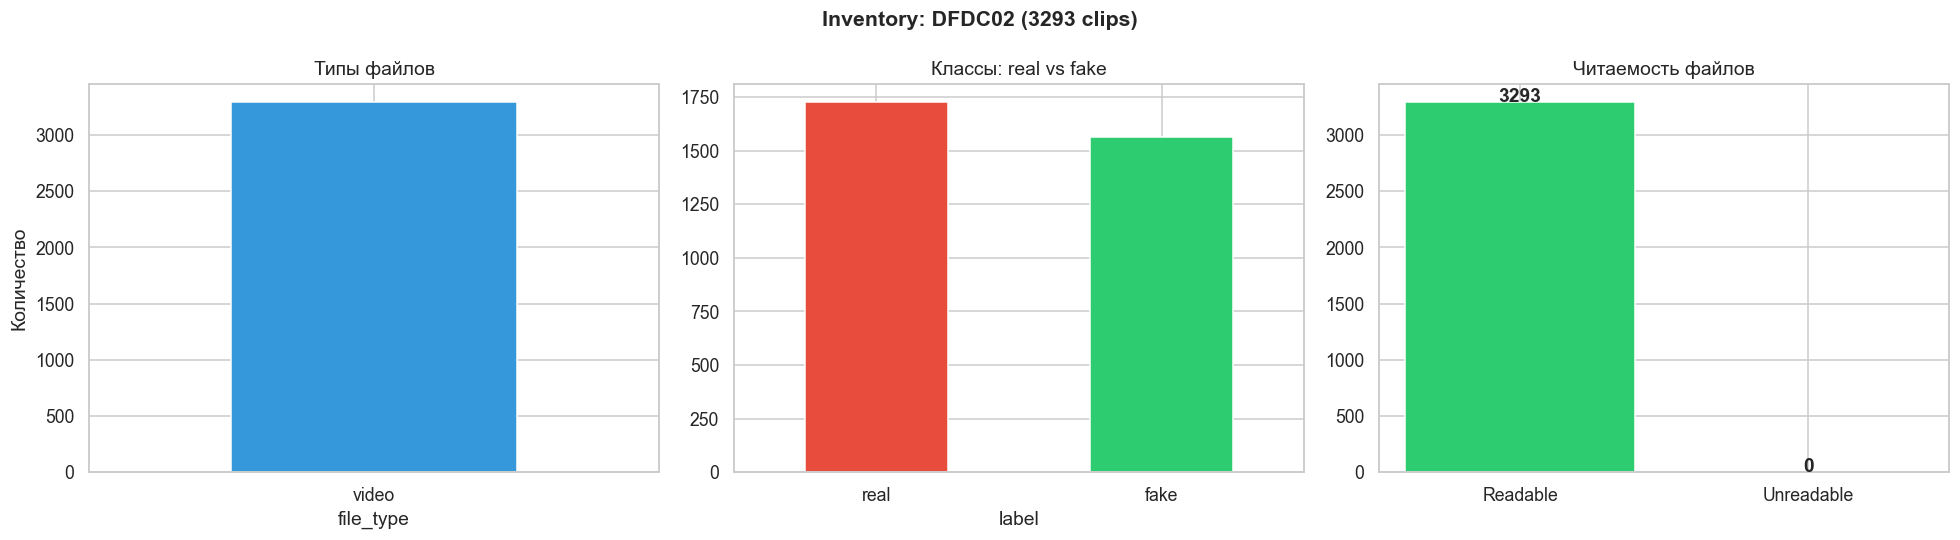

label           fake  real   All
source_dataset                  
DFDC02          1566  1727  3293
All             1566  1727  3293


In [15]:
# Визуализация инвентаризации
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. По типу файла
df["file_type"].value_counts().plot.bar(ax=axes[0], color=["#3498db", "#e67e22"])
axes[0].set_title("Типы файлов")
axes[0].set_ylabel("Количество")
axes[0].tick_params(axis="x", rotation=0)

# 2. По label (real/fake)
df["label"].value_counts().plot.bar(ax=axes[1], color=["#e74c3c", "#2ecc71", "#95a5a6"])
axes[1].set_title("Классы: real vs fake")
axes[1].tick_params(axis="x", rotation=0)

# 3. Readable count
n_readable = int(df["is_readable"].sum())
n_unreadable = len(df) - n_readable
axes[2].bar(["Readable", "Unreadable"], [n_readable, n_unreadable],
            color=["#2ecc71", "#e74c3c"])
axes[2].set_title("Читаемость файлов")
for j, v in enumerate([n_readable, n_unreadable]):
    axes[2].text(j, v + 5, str(v), ha="center", fontweight="bold")

plt.suptitle(f"Inventory: {DATASET_NAME} ({len(df)} clips)", fontsize=14, fontweight="bold")
plt.tight_layout()
save_fig("01_inventory")
plt.show()

# Cross-tab
xt = pd.crosstab(df["source_dataset"], df["label"], margins=True)
save_csv(xt.reset_index(), "dataset_label_crosstab.csv")
print(xt)


## 4. Raw EDA

Распределения ключевых характеристик: длительность, fps, разрешение, размер файла, баланс классов.

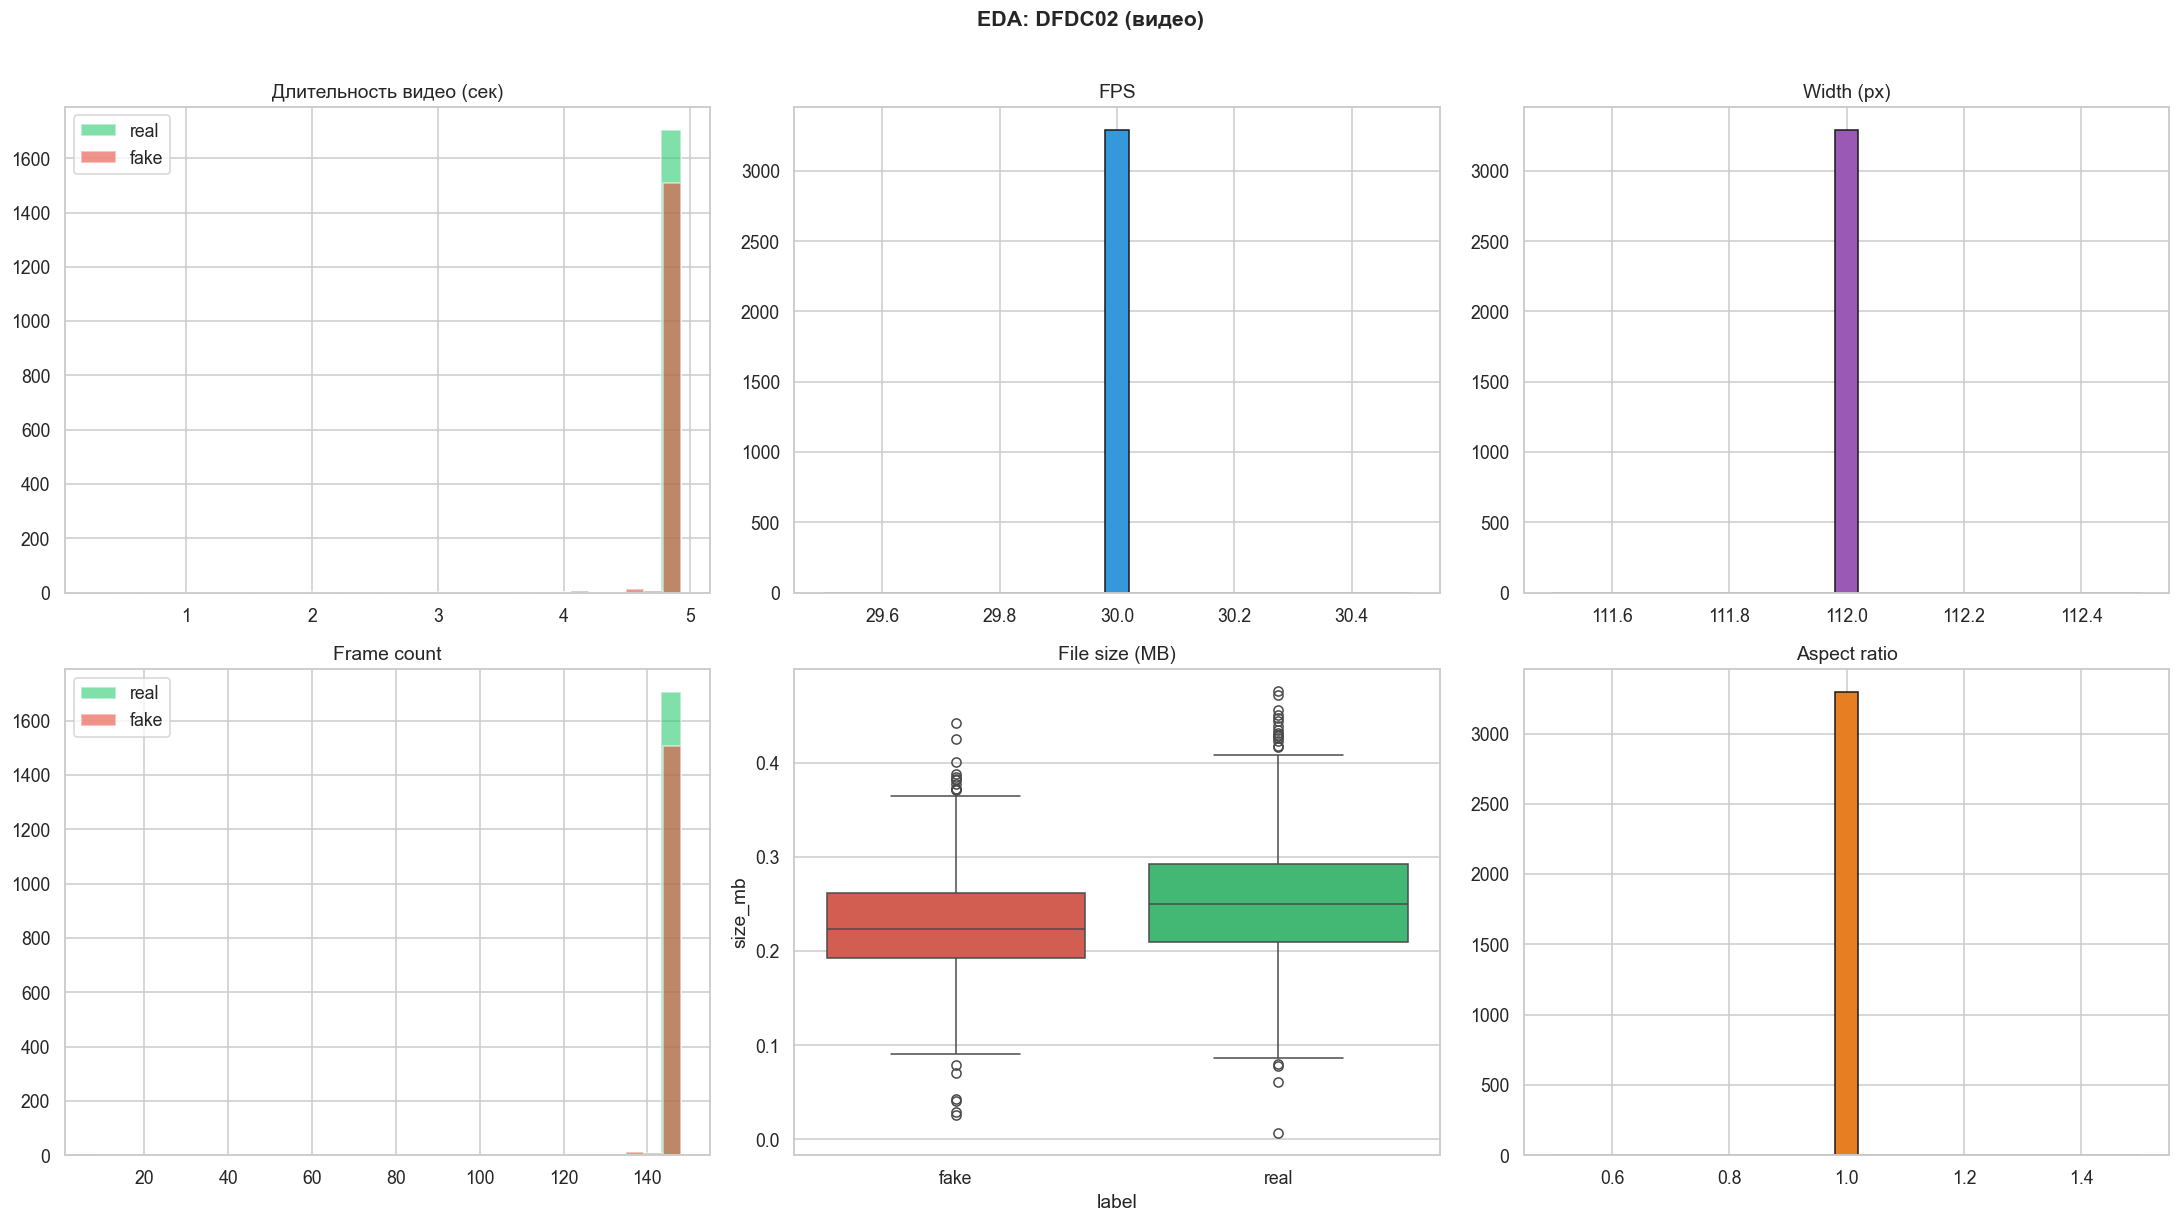

               count      mean      std     min       25%       50%       75%       max
duration_sec  3293.0       4.9      0.2     0.3       4.9       4.9       4.9       4.9
fps           3293.0      30.0      0.0    30.0      30.0      30.0      30.0      30.0
width         3293.0     112.0      0.0   112.0     112.0     112.0     112.0     112.0
height        3293.0     112.0      0.0   112.0     112.0     112.0     112.0     112.0
frame_count   3293.0     147.1      7.2     8.0     148.0     148.0     148.0     148.0
size_bytes    3293.0  240604.8  60573.2  6533.0  199126.0  234261.0  280415.0  476082.0


In [18]:
# === 4.1. Видео EDA ===
dfv = df[(df['file_type']=='video') & (df['is_readable'])].copy()

if len(dfv) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(20, 11))

    # Duration by label.
    for lab, c in [('real','#2ecc71'),('fake','#e74c3c')]:
        s = dfv[dfv['label']==lab]['duration_sec']
        if len(s) > 0: axes[0,0].hist(s, bins=30, alpha=0.6, label=lab, color=c)
    axes[0,0].set_title('Длительность видео (сек)'); axes[0,0].legend()

    # FPS.
    dfv['fps'].hist(ax=axes[0,1], bins=25, color='#3498db', edgecolor='k')
    axes[0,1].set_title('FPS')

    # Resolution width.
    dfv['width'].hist(ax=axes[0,2], bins=25, color='#9b59b6', edgecolor='k')
    axes[0,2].set_title('Width (px)')

    # Frame count by label.
    for lab, c in [('real','#2ecc71'),('fake','#e74c3c')]:
        s = dfv[dfv['label']==lab]['frame_count']
        if len(s) > 0: axes[1,0].hist(s, bins=30, alpha=0.6, label=lab, color=c)
    axes[1,0].set_title('Frame count'); axes[1,0].legend()

    # File size boxplot.
    dfv['size_mb'] = dfv['size_bytes'] / 1e6
    sns.boxplot(data=dfv, x='label', y='size_mb', ax=axes[1,1],
                palette={'real':'#2ecc71','fake':'#e74c3c'})
    axes[1,1].set_title('File size (MB)')

    # Aspect ratio.
    dfv['aspect_ratio'].hist(ax=axes[1,2], bins=25, color='#e67e22', edgecolor='k')
    axes[1,2].set_title('Aspect ratio')

    plt.suptitle('EDA: DFDC02 (видео)', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    save_fig("02_video_eda")
    plt.show()

    # Summary stats.
    stats_v = dfv[['duration_sec','fps','width','height','frame_count','size_bytes']].describe().T
    stats_v.columns = ['count','mean','std','min','25%','50%','75%','max']
    save_csv(stats_v.reset_index().rename(columns={'index':'metric'}), "summary_video_stats.csv")
    print(stats_v.round(1))
else:
    print("Видео не найдены — пропуск.")

In [20]:
# === Image EDA ===
# Текущий датасет содержит только видеоклипы, изображений нет.
n_images = int((df["file_type"] == "image").sum()) if not df.empty else 0
if n_images == 0:
    print("Image EDA skipped: current dataset contains only video clips.")
    print(f"Videos: {int((df['file_type'] == 'video').sum())}, Images: {n_images}")
else:
    print(f"Found {n_images} images — running image EDA...")
    # (image EDA code would go here if needed)


Image EDA skipped: current dataset contains only video clips.
Videos: 3293, Images: 0


## 5. Data Quality Audit

Систематическая проверка каждого sample на проблемы. Результат: issue_flags для каждого sample + problem_registry.

In [25]:
VALID_FPS_RANGE = (5, 120)

def audit_sample(row: pd.Series) -> List[str]:
    """Возвращает список проблем (issue flags) для одного sample."""
    flags = []

    if not row['is_readable']:
        flags.append('unreadable')

    if row['size_bytes'] == 0:
        flags.append('empty_file')

    if row['size_bytes'] < 1024:
        flags.append('tiny_file')

    if row['file_type'] == 'video':
        if row['duration_sec'] <= 0:
            flags.append('zero_duration')
        elif row['duration_sec'] < MIN_DURATION_SEC:
            flags.append('too_short')

        if row['fps'] <= 0 or np.isnan(row['fps']) or np.isinf(row['fps']):
            flags.append('invalid_fps')
        elif row['fps'] < VALID_FPS_RANGE[0] or row['fps'] > VALID_FPS_RANGE[1]:
            flags.append('suspicious_fps')

        if row['frame_count'] < TARGET_CLIP_LEN:
            flags.append('too_few_frames')

    if row['is_readable']:
        if min(row['width'], row['height']) < MIN_RESOLUTION:
            flags.append('low_resolution')

        ar = row['aspect_ratio']
        if ar > 0 and (ar < 0.25 or ar > 4.0):
            flags.append('extreme_aspect_ratio')

    if row['label'] == 'unknown':
        flags.append('missing_label')

    return flags

print("Аудит качества данных...")
issue_lists = []
for _, row in tqdm(df.iterrows(), total=len(df), desc="Quality audit"):
    flags = audit_sample(row)
    issue_lists.append('|'.join(flags) if flags else '')

df['issue_flags'] = issue_lists
df['has_issues'] = df['issue_flags'].str.len() > 0
df['issue_count'] = df['issue_flags'].apply(lambda x: len(x.split('|')) if x else 0)

print(f"\nSamples с проблемами: {df['has_issues'].sum()} / {len(df)} "
      f"({df['has_issues'].mean()*100:.1f}%)")

Аудит качества данных...


Quality audit: 100%|█████████████████████| 3293/3293 [00:00<00:00, 31100.96it/s]


Samples с проблемами: 1 / 3293 (0.0%)


In [27]:
# Проверка дубликатов по hash
print("Проверка hash-дубликатов...")

hash_counts = df.loc[df["file_hash"].notna(), "file_hash"].value_counts()
dup_hashes = hash_counts[hash_counts > 1]

n_dup_hash_groups = int(len(dup_hashes))
n_dup_hash_files = int(df["file_hash"].isin(dup_hashes.index).sum())
n_dup_hash_extra = int(n_dup_hash_files - n_dup_hash_groups)

print(f"Групп hash-дубликатов: {n_dup_hash_groups}")
print(f"Файлов в duplicate-hash группах: {n_dup_hash_files}")
print(f'Лишних копий: {n_dup_hash_extra}')

# Помечаем duplicate_hash у всех повторов, кроме первого
dup_hash_mask = df.duplicated(subset=["file_hash"], keep="first") & df["file_hash"].notna()
df.loc[dup_hash_mask, "issue_flags"] = df.loc[dup_hash_mask, "issue_flags"].apply(
    lambda x: f"{x}|duplicate_hash" if x else "duplicate_hash"
)

# Проверка дубликатов по имени файла внутри одного датасета
print("Проверка filename-дубликатов...")
df["basename"] = df["path"].apply(lambda x: Path(x).name)

fname_dup_groups = (
    df.groupby(["source_dataset", "basename"])
      .size()
      .reset_index(name="count")
)
fname_dup_groups = fname_dup_groups[fname_dup_groups["count"] > 1]

n_fname_dup_groups = int(len(fname_dup_groups))
n_fname_dup_files = int(
    df.merge(
        fname_dup_groups[["source_dataset", "basename"]],
        on=["source_dataset", "basename"],
        how="inner"
    ).shape[0]
)

print(f"Групп filename-дубликатов: {n_fname_dup_groups}")
print(f"Файлов в filename-duplicate группах: {n_fname_dup_files}")

# Помечаем duplicate_name у всех повторов, кроме первого
dup_name_mask = df.duplicated(subset=["source_dataset", "basename"], keep="first")
df.loc[dup_name_mask, "issue_flags"] = df.loc[dup_name_mask, "issue_flags"].apply(
    lambda x: f"{x}|duplicate_name" if x else "duplicate_name"
)

Проверка hash-дубликатов...
Групп hash-дубликатов: 0
Файлов в duplicate-hash группах: 0
Лишних копий: 0
Проверка filename-дубликатов...
Групп filename-дубликатов: 0
Файлов в filename-duplicate группах: 0


                count datasets
issue                         
too_few_frames      1   DFDC02
too_short           1   DFDC02


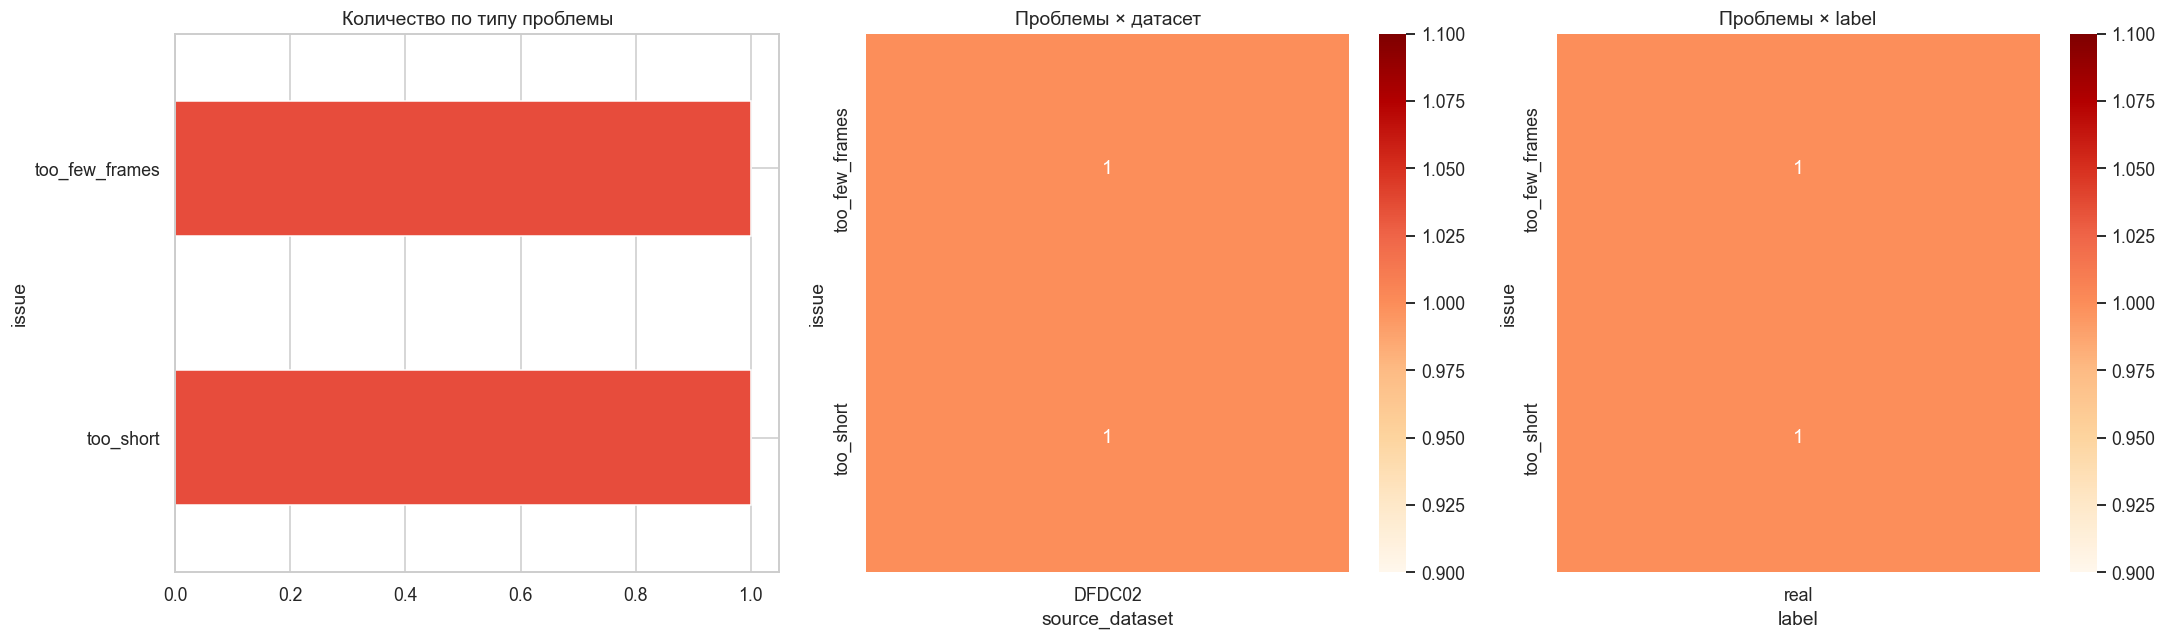


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  QUALITY AUDIT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Samples с проблемами: 1 / 3293
  Типов проблем: 2
  Hash-дубликат групп: 0
  Лишних hash-копий: 0
  Top проблема: too_few_frames
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━



In [29]:
# === Problem Registry ===
all_flags = []
for _, row in df[df["issue_flags"].fillna("").str.len() > 0].iterrows():
    for flag in row["issue_flags"].split("|"):
        flag = flag.strip()
        if not flag:
            continue
        all_flags.append({
            "sample_id": row["sample_id"],
            "path": row["path"],
            "source_dataset": row["source_dataset"],
            "label": row["label"],
            "issue": flag,
        })

df_problems = pd.DataFrame(all_flags) if all_flags else pd.DataFrame(
    columns=["sample_id", "path", "source_dataset", "label", "issue"]
)

save_csv(df_problems, "problem_registry.csv")

issue_summary = pd.DataFrame(columns=["count", "datasets"])

if len(df_problems) > 0:
    issue_summary = (
        df_problems.groupby("issue")
        .agg(
            count=("sample_id", "count"),
            datasets=("source_dataset", lambda x: ", ".join(sorted(x.unique()))),
        )
        .sort_values("count", ascending=False)
    )
    save_csv(issue_summary.reset_index(), "quality_issue_summary.csv")
    print(issue_summary)

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # 1. Count по типу проблемы
    issue_summary["count"].plot.barh(ax=axes[0], color="#e74c3c")
    axes[0].set_title("Количество по типу проблемы")
    axes[0].invert_yaxis()

    # 2. Heatmap issue × dataset
    xt_ds = pd.crosstab(df_problems["issue"], df_problems["source_dataset"])
    sns.heatmap(xt_ds, annot=True, fmt="d", cmap="OrRd", ax=axes[1])
    axes[1].set_title("Проблемы × датасет")

    # 3. Heatmap issue × label
    xt_lb = pd.crosstab(df_problems["issue"], df_problems["label"])
    sns.heatmap(xt_lb, annot=True, fmt="d", cmap="OrRd", ax=axes[2])
    axes[2].set_title("Проблемы × label")

    plt.tight_layout()
    save_fig("04_quality_audit")
    plt.show()
else:
    print("Проблем не обнаружено.")

mini_report("QUALITY AUDIT", {
    "Samples с проблемами": f"{int(df['has_issues'].sum())} / {len(df)}",
    "Типов проблем": int(df_problems["issue"].nunique()) if len(df_problems) > 0 else 0,
    "Hash-дубликат групп": n_dup_hash_groups,
    "Лишних hash-копий": n_dup_hash_extra,
    "Top проблема": issue_summary.index[0] if len(issue_summary) > 0 else "нет",
})

## 6. Leakage Risk Analysis

Определяем group_id для leakage-safe split. Проверяем: нет ли одного и того же источника в разных потенциальных split'ах.

In [32]:
print("=== LEAKAGE RISK ANALYSIS ===\n")

# 1. Анализ group_id
print(f"Уникальных group_id: {df['group_id'].nunique()}")
group_sizes = df.groupby("group_id").size()
print(f"Размеры групп: min={group_sizes.min()}, "
      f"median={group_sizes.median():.0f}, max={group_sizes.max()}")

# Интерпретация
if group_sizes.max() == 1:
    print("\n⚠ group_id уникален для каждого sample (file-level identifier).")
    print("  Leakage audit ограничен: один sample на группу.")
    print("  Split будет file-level, что допустимо для video-clip dataset.")
else:
    print(f"\nГруппы с >1 sample: {int((group_sizes > 1).sum())}")

# 2. Проверка: есть ли группы с обоими labels
group_labels = df.groupby("group_id")["label"].nunique()
mixed_groups = group_labels[group_labels > 1]
print(f"\nГруппы с разными labels: {len(mixed_groups)}")

if len(mixed_groups) > 0 and len(mixed_groups) <= 10:
    for gid in mixed_groups.index:
        sub = df[df["group_id"] == gid]
        print(f"  {gid}: {dict(sub['label'].value_counts())}")

# 3. Substring match check (real/fake pair leakage)
leakage_candidates = []
real_stems = sorted(set(df[df["label"] == "real"]["group_id"]))[:300]
fake_stems = sorted(set(df[df["label"] == "fake"]["group_id"]))[:300]

for rs in real_stems:
    for fs in fake_stems:
        if rs == fs:
            leakage_candidates.append({"type": "exact_match", "real_id": rs, "fake_id": fs})
        elif rs in fs or fs in rs:
            leakage_candidates.append({"type": "substring_match", "real_id": rs, "fake_id": fs})

df_leakage_candidates = pd.DataFrame(leakage_candidates)
save_csv(df_leakage_candidates, "leakage_candidates.csv")
print(f"\nLeakage-кандидаты (substring match): {len(df_leakage_candidates)}")

# 4. Сохраняем leakage groups
save_csv(group_sizes.reset_index().rename(columns={"group_id": "group_id", 0: "size"}), "leakage_groups.csv")

mini_report("LEAKAGE SUMMARY", {
    "Unique group_ids": df["group_id"].nunique(),
    "Max group size": int(group_sizes.max()),
    "Mixed-label groups": len(mixed_groups),
    "Substring match candidates": len(df_leakage_candidates),
    "Assessment": "file-level split (1 sample per group)" if group_sizes.max() == 1 else "group-level split needed",
})


=== LEAKAGE RISK ANALYSIS ===

Уникальных group_id: 3293
Размеры групп: min=1, median=1, max=1

⚠ group_id уникален для каждого sample (file-level identifier).
  Leakage audit ограничен: один sample на группу.
  Split будет file-level, что допустимо для video-clip dataset.

Группы с разными labels: 0

Leakage-кандидаты (substring match): 0

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  LEAKAGE SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Unique group_ids: 3293
  Max group size: 1
  Mixed-label groups: 0
  Substring match candidates: 0
  Assessment: file-level split (1 sample per group)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━



## 7. Frame-level Analysis

Извлекаем кадры, визуализируем примеры real/fake, выявляем проблемные случаи.

In [35]:
def extract_frames_uniform(video_path: str, n: int = 5) -> List[np.ndarray]:
    """Извлекает n кадров из видео (uniform sampling). Возвращает RGB frames."""
    frames = []
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return frames
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release()
        return frames
    indices = np.linspace(0, total-1, n, dtype=int)
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    cap.release()
    return frames

def load_image_rgb(path: str) -> Optional[np.ndarray]:
    img = cv2.imread(path)
    if img is not None:
        return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return None

def show_grid(images, titles, suptitle, ncols=5, figsize=(20,8)):
    n = len(images)
    nrows = max(1, (n + ncols - 1) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.array(axes).flatten()
    for i, ax in enumerate(axes):
        if i < n and images[i] is not None:
            ax.imshow(images[i])
            ax.set_title(titles[i] if i < len(titles) else '', fontsize=8)
        ax.axis('off')
    plt.suptitle(suptitle, fontsize=13, fontweight='bold')
    plt.tight_layout()
    return fig

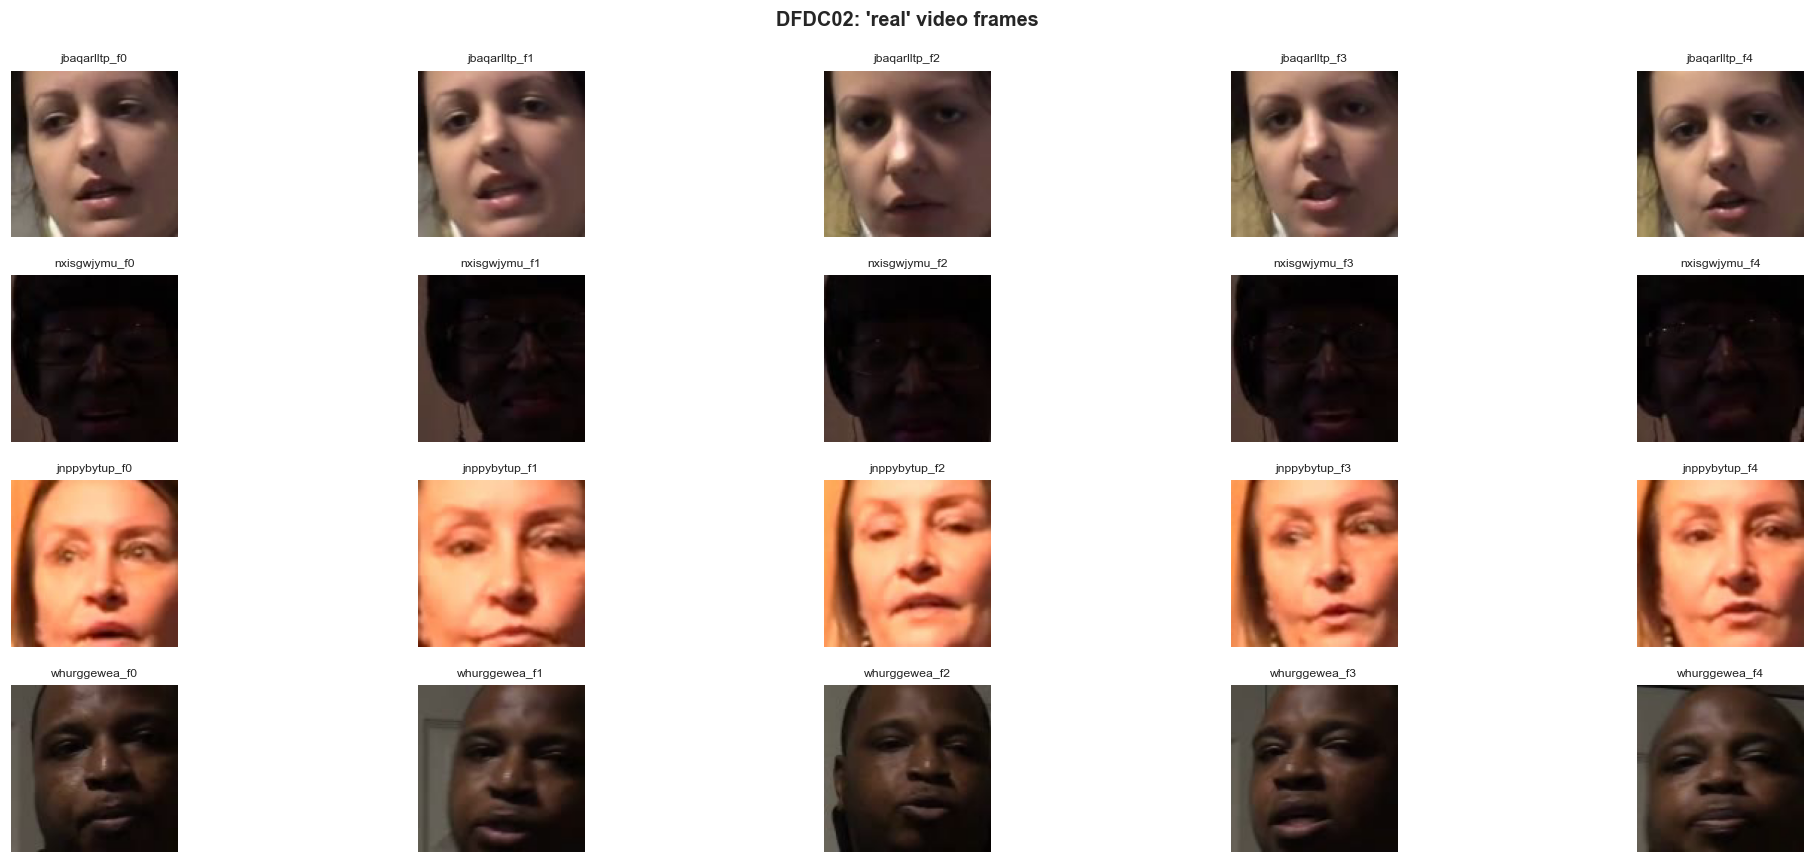

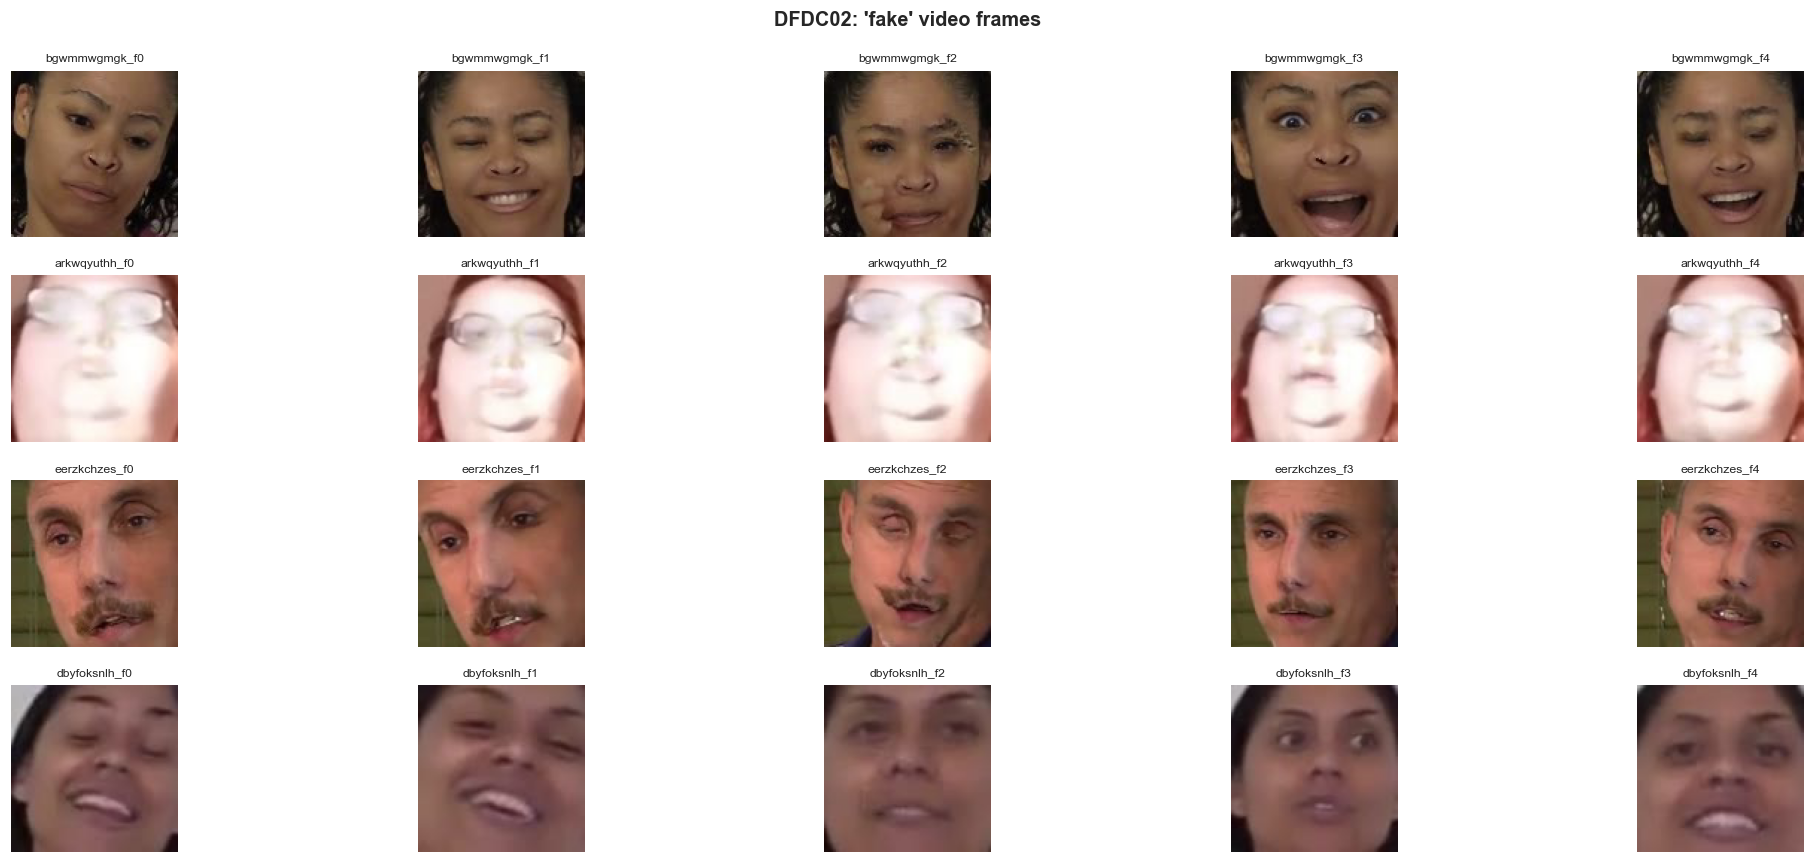

In [37]:
# === 7.1. Примеры кадров из видеоклипов ===
dfv_ok = df[(df["file_type"] == "video") & df["is_readable"]].copy()

if len(dfv_ok) == 0:
    # Fallback: try as images
    dfi_ok = df[df["is_readable"]].copy()
    for label in ["real", "fake"]:
        subset = dfi_ok[dfi_ok["label"] == label]
        if len(subset) < 5:
            continue
        sample_paths = subset.sample(min(10, len(subset)), random_state=RANDOM_SEED)["path"].tolist()
        imgs = [load_image_rgb(p) for p in sample_paths]
        imgs = [im for im in imgs if im is not None]
        titles = [Path(p).name[:20] for p in sample_paths[:len(imgs)]]
        if imgs:
            fig = show_grid(imgs, titles, f"{DATASET_NAME}: '{label}' examples")
            save_fig(f"05_{label}_examples")
            plt.show()
else:
    # Video dataset: extract frames from sample videos
    for label in ["real", "fake"]:
        subset = dfv_ok[dfv_ok["label"] == label]
        if len(subset) < 2:
            continue
        sample_vids = subset.sample(min(4, len(subset)), random_state=RANDOM_SEED)
        all_frames, all_titles = [], []
        for _, row in sample_vids.iterrows():
            frames = extract_frames_uniform(row["path"], n=5)
            stem = Path(row["path"]).stem[:12]
            for fi, f in enumerate(frames):
                all_frames.append(f)
                all_titles.append(f"{stem}_f{fi}")
        if all_frames:
            fig = show_grid(all_frames, all_titles,
                          f"{DATASET_NAME}: '{label}' video frames", ncols=5)
            save_fig(f"05_{label}_examples")
            plt.show()


In [39]:
# === Frame sampling metadata ===
# Сохраняем frame-level metadata для face detection и quality analysis

frame_meta_records = []
sample_for_frames = df[df["is_readable"]].sample(
    min(MAX_VIDEOS_FOR_HEAVY_ANALYSIS, len(df[df["is_readable"]])),
    random_state=RANDOM_SEED
)

for _, row in tqdm(sample_for_frames.iterrows(), total=len(sample_for_frames),
                   desc="Frame sampling"):
    if row["file_type"] == "video":
        frames = extract_frames_uniform(row["path"], n=MAX_FRAMES_PER_VIDEO_FOR_ANALYSIS)
    else:
        img = load_image_rgb(row["path"])
        frames = [img] if img is not None else []

    for fi, frame in enumerate(frames):
        frame_meta_records.append({
            "sample_id": row.get("sample_id", row.name),
            "path": row["path"],
            "source_dataset": row.get("source_dataset", DATASET_NAME),
            "label": row["label"],
            "frame_idx": fi,
            "frame_h": frame.shape[0] if frame is not None else 0,
            "frame_w": frame.shape[1] if frame is not None else 0,
        })

df_frame_meta = pd.DataFrame(frame_meta_records)
save_csv(df_frame_meta, "frame_samples_metadata.csv")
print(f"Frame metadata: {len(df_frame_meta)} frames from {len(sample_for_frames)} videos")


Frame sampling: 100%|████████████████████████| 500/500 [00:02<00:00, 200.59it/s]


Frame metadata: 4000 frames from 500 videos


## 8. Face-level Analysis

Face detection на sampled frames. Для каждого кадра: число лиц, bbox, face_area_ratio.
Для каждого видео: face_detection_ratio, mean_face_area_ratio.

In [41]:
# =====================================================================
# 8. FACE-LEVEL ANALYSIS
# =====================================================================

if RUN_HEAVY_ANALYSIS:
    face_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
    )

    def detect_faces(image_rgb: np.ndarray) -> List[dict]:
        """Детекция лиц. Возвращает список bbox + area_ratio."""
        if image_rgb is None:
            return []

        gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
        img_h, img_w = gray.shape[:2]
        img_area = max(img_h * img_w, 1)

        rects = face_cascade.detectMultiScale(
            gray,
            scaleFactor=1.1,
            minNeighbors=5,
            minSize=(20, 20),
        )

        faces = []
        if isinstance(rects, np.ndarray) and len(rects) > 0:
            for (x, y, w, h) in rects:
                faces.append({
                    "x": int(x),
                    "y": int(y),
                    "w": int(w),
                    "h": int(h),
                    "area_ratio": round((w * h) / img_area, 6),
                })
        return faces

    print("Face detection on sampled frames...")

    face_records = []
    failed_face_cases = []

    readable_df = df[df["is_readable"]].copy()
    sample_for_face = readable_df.sample(
        min(MAX_VIDEOS_FOR_HEAVY_ANALYSIS, len(readable_df)),
        random_state=RANDOM_SEED
    )

    for _, row in tqdm(sample_for_face.iterrows(), total=len(sample_for_face), desc="Face detection"):
        if row["file_type"] == "video":
            frames = extract_frames_uniform(row["path"], n=MAX_FRAMES_PER_VIDEO_FOR_ANALYSIS)
        else:
            img = load_image_rgb(row["path"])
            frames = [img] if img is not None else []

        if not frames:
            failed_face_cases.append({
                "sample_id": row["sample_id"],
                "path": row["path"],
                "source_dataset": row["source_dataset"],
                "label": row["label"],
                "reason": "no_frames_loaded",
            })
            continue

        for fi, frame in enumerate(frames):
            if frame is None:
                failed_face_cases.append({
                    "sample_id": row["sample_id"],
                    "path": row["path"],
                    "source_dataset": row["source_dataset"],
                    "label": row["label"],
                    "reason": f"frame_{fi}_is_none",
                })
                continue

            faces = detect_faces(frame)
            n_faces = len(faces)
            largest_face_area = max([f["area_ratio"] for f in faces], default=0.0)

            if n_faces == 0:
                failed_face_cases.append({
                    "sample_id": row["sample_id"],
                    "path": row["path"],
                    "source_dataset": row["source_dataset"],
                    "label": row["label"],
                    "reason": "no_face_detected",
                    "frame_idx": fi,
                })

            for face_idx, f in enumerate(faces if faces else [{}]):
                face_records.append({
                    "sample_id": row["sample_id"],
                    "frame_idx": fi,
                    "face_idx": face_idx if n_faces > 0 else -1,
                    "path": row["path"],
                    "label": row["label"],
                    "source_dataset": row["source_dataset"],
                    "n_faces": n_faces,
                    "face_detected": n_faces > 0,
                    "multi_face": n_faces > 1,
                    "largest_face_area_ratio": largest_face_area,
                    "x": f.get("x", None),
                    "y": f.get("y", None),
                    "w": f.get("w", None),
                    "h": f.get("h", None),
                    "face_area_ratio": f.get("area_ratio", 0.0),
                })

    df_faces = pd.DataFrame(face_records)
    df_failed_faces = pd.DataFrame(failed_face_cases)

    save_csv(df_faces, "face_detections.csv")
    save_csv(df_failed_faces, "failed_face_cases.csv")

    if len(df_faces) > 0:
        face_video_summary = (
            df_faces.groupby("sample_id")
            .agg(
                path=("path", "first"),
                label=("label", "first"),
                source_dataset=("source_dataset", "first"),
                sampled_frames=("frame_idx", "nunique"),
                frames_with_face=("face_detected", lambda x: int(x.sum())),
                face_detection_ratio=("face_detected", lambda x: round(float(np.mean(x)), 4)),
                mean_face_area_ratio=("largest_face_area_ratio", lambda x: round(float(np.mean(x)), 6)),
                max_face_area_ratio=("largest_face_area_ratio", lambda x: round(float(np.max(x)), 6)),
                multi_face_ratio=("multi_face", lambda x: round(float(np.mean(x)), 4)),
                no_face_ratio=("face_detected", lambda x: round(float(1.0 - np.mean(x)), 4)),
            )
            .reset_index()
        )
    else:
        face_video_summary = pd.DataFrame(columns=[
            "sample_id", "path", "label", "source_dataset", "sampled_frames",
            "frames_with_face", "face_detection_ratio", "mean_face_area_ratio",
            "max_face_area_ratio", "multi_face_ratio", "no_face_ratio"
        ])

    save_csv(face_video_summary, "face_video_summary.csv")

    print(f"Face detections: {len(df_faces)} rows")
    print(f"Face video summary: {len(face_video_summary)} samples")
    print(f"Failed face cases: {len(df_failed_faces)}")

else:
    print("Face analysis skipped (RUN_HEAVY_ANALYSIS=False)")
    df_faces = pd.DataFrame()
    df_failed_faces = pd.DataFrame()
    face_video_summary = pd.DataFrame()

Face detection on sampled frames...


Face detection: 100%|█████████████████████████| 500/500 [00:05<00:00, 84.23it/s]

Face detections: 4005 rows
Face video summary: 500 samples
Failed face cases: 3107



Samples с низким face detection (<0.55): 442 / 500 (88.4%)


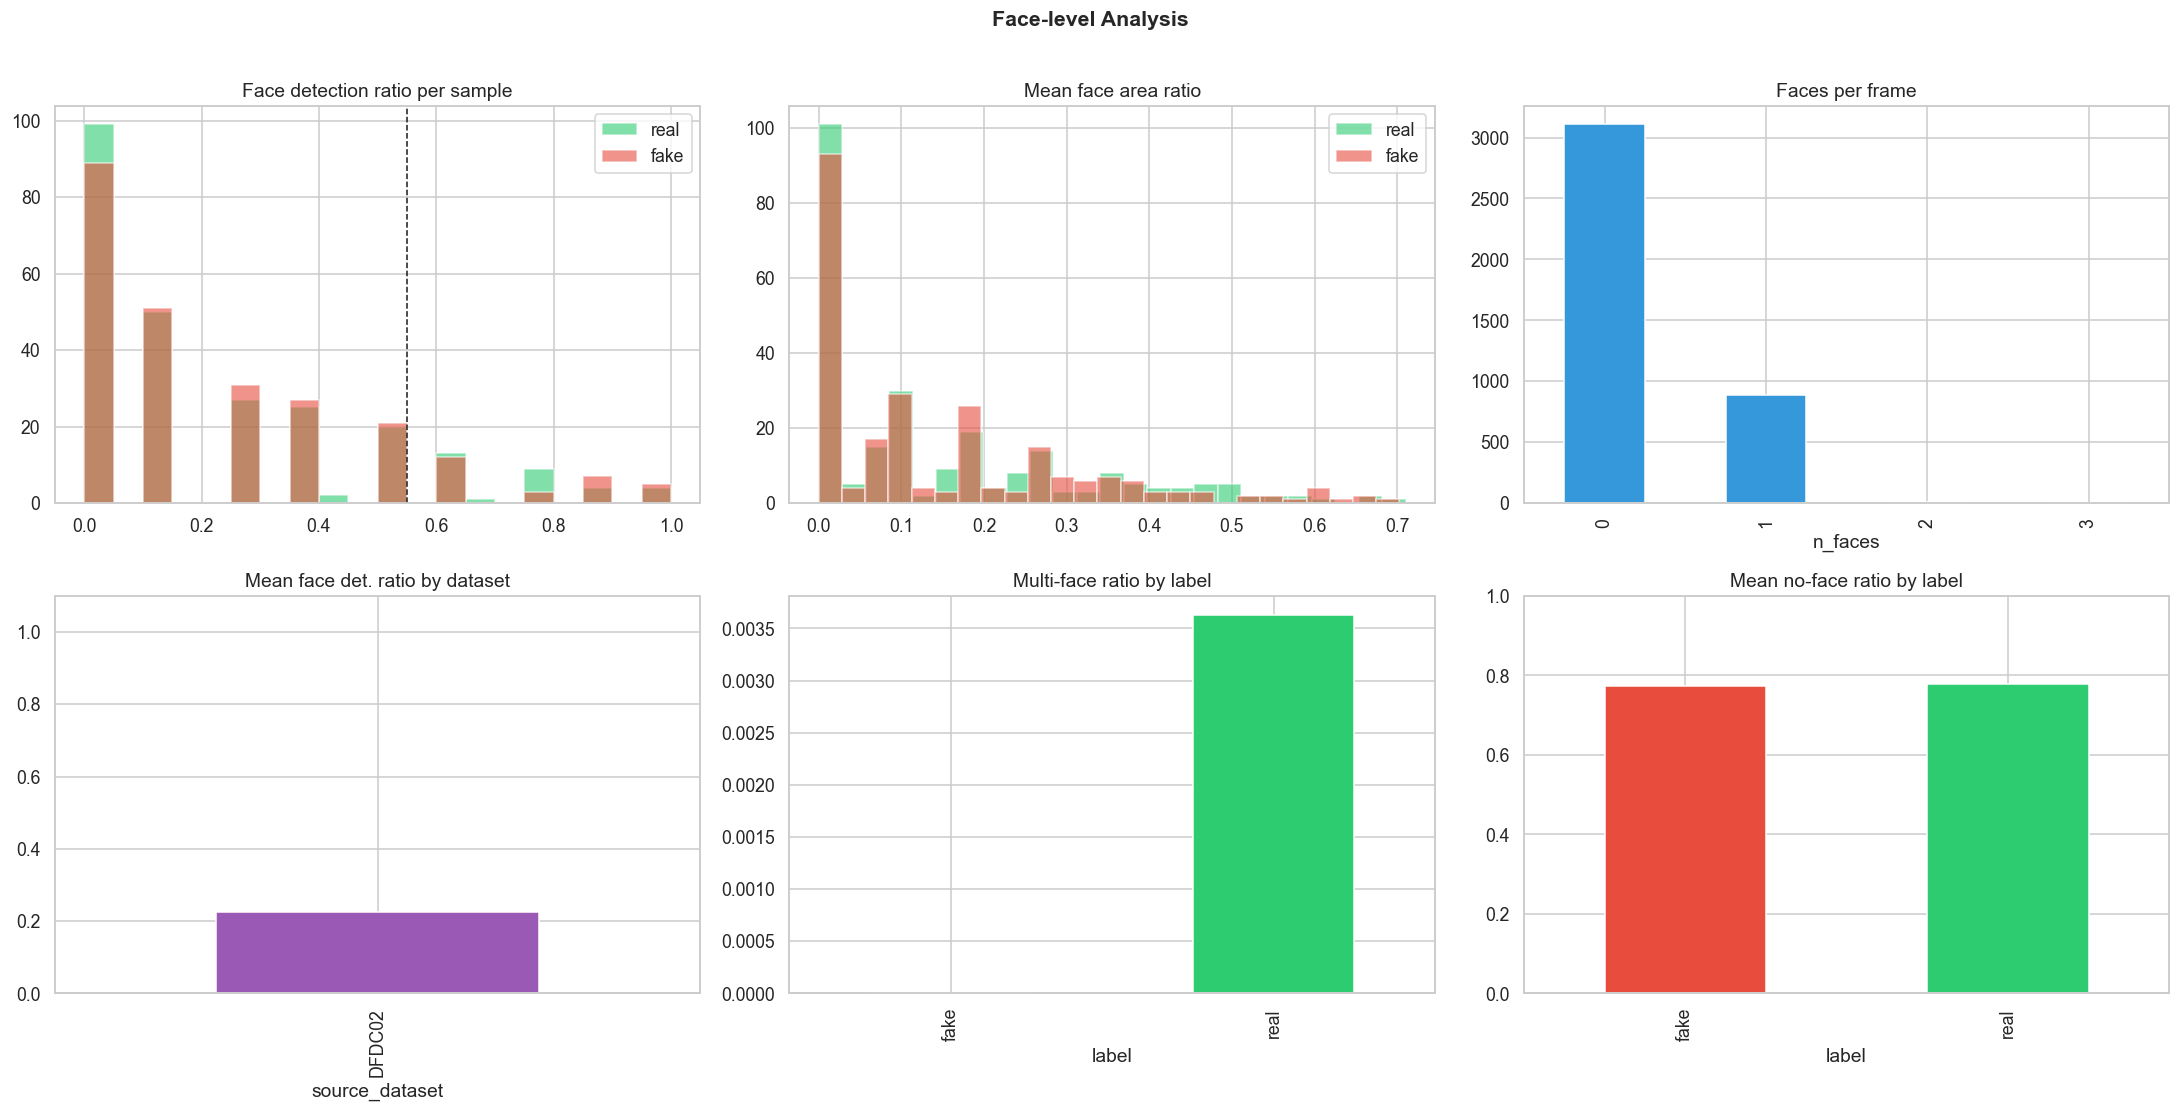


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  FACE ANALYSIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Samples analyzed: 500
  Mean face det. ratio: 0.224
  Samples failing face threshold: 442 (88.4%)
  Mean face area ratio: 0.145
  Multi-face frames: 9 / 4005
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━



In [44]:
# === Video-level face summary / visualization ===
if len(face_video_summary) > 0:
    failed_face_summary = face_video_summary[
        face_video_summary["face_detection_ratio"] < MIN_VALID_FACE_RATIO
    ].copy()

    save_csv(face_video_summary, "face_video_summary.csv")
    save_csv(failed_face_summary, "failed_face_summary.csv")

    print(
        f"\nSamples с низким face detection (<{MIN_VALID_FACE_RATIO}): "
        f"{len(failed_face_summary)} / {len(face_video_summary)} "
        f"({len(failed_face_summary)/len(face_video_summary)*100:.1f}%)"
    )

    fig, axes = plt.subplots(2, 3, figsize=(20, 10))

    # 1. Face detection ratio distribution
    for lab, c in [("real", "#2ecc71"), ("fake", "#e74c3c")]:
        s = face_video_summary[face_video_summary["label"] == lab]["face_detection_ratio"]
        if len(s) > 0:
            axes[0, 0].hist(s, bins=20, alpha=0.6, label=lab, color=c)
    axes[0, 0].set_title("Face detection ratio per sample")
    axes[0, 0].legend()
    axes[0, 0].axvline(MIN_VALID_FACE_RATIO, color="k", ls="--", lw=1)

    # 2. Mean face area ratio
    for lab, c in [("real", "#2ecc71"), ("fake", "#e74c3c")]:
        s = face_video_summary[face_video_summary["label"] == lab]["mean_face_area_ratio"]
        if len(s) > 0:
            axes[0, 1].hist(s, bins=25, alpha=0.6, label=lab, color=c)
    axes[0, 1].set_title("Mean face area ratio")
    axes[0, 1].legend()

    # 3. Faces per frame
    if len(df_faces) > 0:
        df_faces["n_faces"].value_counts().sort_index().plot.bar(ax=axes[0, 2], color="#3498db")
    axes[0, 2].set_title("Faces per frame")

    # 4. Face detection by dataset
    face_video_summary.groupby("source_dataset")["face_detection_ratio"].mean().plot.bar(
        ax=axes[1, 0], color="#9b59b6"
    )
    axes[1, 0].set_title("Mean face det. ratio by dataset")
    axes[1, 0].set_ylim(0, 1.1)

    # 5. Multi-face ratio by label
    face_video_summary.groupby("label")["multi_face_ratio"].mean().plot.bar(
        ax=axes[1, 1], color=["#e74c3c", "#2ecc71"]
    )
    axes[1, 1].set_title("Multi-face ratio by label")

    # 6. No-face ratio by label
    face_video_summary.groupby("label")["no_face_ratio"].mean().plot.bar(
        ax=axes[1, 2], color=["#e74c3c", "#2ecc71"]
    )
    axes[1, 2].set_title("Mean no-face ratio by label")
    axes[1, 2].set_ylim(0, 1.0)

    plt.suptitle("Face-level Analysis", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    save_fig("07_face_analysis")
    plt.show()

    mini_report("FACE ANALYSIS", {
        "Samples analyzed": len(face_video_summary),
        "Mean face det. ratio": f"{face_video_summary['face_detection_ratio'].mean():.3f}",
        "Samples failing face threshold": f"{len(failed_face_summary)} ({len(failed_face_summary)/len(face_video_summary)*100:.1f}%)",
        "Mean face area ratio": f"{face_video_summary['mean_face_area_ratio'].mean():.3f}",
        "Multi-face frames": f"{int(df_faces['multi_face'].sum())} / {len(df_faces)}" if len(df_faces) > 0 else "0 / 0",
    })
else:
    print("Face video summary is empty — skipping face summary plots.")

## 9. Quality Metrics Analysis

Blur, brightness, contrast, saturation, entropy — на кадрах и face crop'ах.
Проверяем: нет ли качественного bias между real и fake.

In [47]:
# =====================================================================
# 9. QUALITY METRICS ANALYSIS
# =====================================================================

def compute_quality(image_rgb: np.ndarray) -> dict:
    """Метрики качества одного RGB-кадра / crop."""
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
    hsv = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2HSV)

    hist = np.histogram(gray, bins=256, range=(0, 256))[0].astype(np.float64)
    prob = hist / max(hist.sum(), 1.0)
    entropy = -np.sum(prob * np.log2(prob + 1e-10))

    return {
        "blur_laplacian": round(float(cv2.Laplacian(gray, cv2.CV_64F).var()), 4),
        "brightness": round(float(gray.mean()), 4),
        "contrast": round(float(gray.std()), 4),
        "saturation": round(float(hsv[:, :, 1].mean()), 4),
        "entropy": round(float(entropy), 4),
    }

if RUN_HEAVY_ANALYSIS:
    print("Quality metrics на sampled frames...")

    quality_records = []
    q_sample = df[df["is_readable"]].sample(
        min(MAX_VIDEOS_FOR_HEAVY_ANALYSIS, len(df[df["is_readable"]])),
        random_state=RANDOM_SEED
    )

    for _, row in tqdm(q_sample.iterrows(), total=len(q_sample), desc="Frame quality"):
        if row["file_type"] == "video":
            frames = extract_frames_uniform(row["path"], n=min(3, MAX_FRAMES_PER_VIDEO_FOR_ANALYSIS))
        else:
            img = load_image_rgb(row["path"])
            frames = [img] if img is not None else []

        for fi, frame in enumerate(frames):
            if frame is None:
                continue

            qm = compute_quality(frame)
            qm.update({
                "sample_id": row["sample_id"],
                "frame_idx": fi,
                "path": row["path"],
                "label": row["label"],
                "source_dataset": row["source_dataset"],
                "height": int(frame.shape[0]),
                "width": int(frame.shape[1]),
            })
            quality_records.append(qm)

    df_quality = pd.DataFrame(quality_records)
    save_csv(df_quality, "frame_quality_metrics.csv")

    # Face crop quality
    face_quality_records = []

    if len(df_faces) > 0:
        print("Quality metrics на face crops...")

        # берем только реальные детекции лиц
        df_face_boxes = df_faces[df_faces["face_detected"] == True].copy()

        # ограничим объем
        face_box_sample = df_face_boxes.sample(
            min(300, len(df_face_boxes)),
            random_state=RANDOM_SEED
        ) if len(df_face_boxes) > 0 else pd.DataFrame()

        for _, row in tqdm(face_box_sample.iterrows(), total=len(face_box_sample), desc="Face crop quality"):
            img = load_image_rgb(row["path"])
            if img is None:
                continue

            x, y, w, h = row["x"], row["y"], row["w"], row["h"]
            if any(pd.isna(v) for v in [x, y, w, h]):
                continue

            x, y, w, h = int(x), int(y), int(w), int(h)
            if w <= 0 or h <= 0:
                continue

            crop = img[y:y+h, x:x+w]
            if crop.size == 0:
                continue

            qm = compute_quality(crop)
            qm.update({
                "sample_id": row["sample_id"],
                "frame_idx": row["frame_idx"],
                "path": row["path"],
                "label": row["label"],
                "source_dataset": row["source_dataset"],
                "face_w": w,
                "face_h": h,
                "face_area_ratio": row["face_area_ratio"],
            })
            face_quality_records.append(qm)

    df_face_quality = pd.DataFrame(face_quality_records)
    save_csv(df_face_quality, "face_quality_metrics.csv")

    print(f"Frame quality records: {len(df_quality)}")
    print(f"Face crop quality records: {len(df_face_quality)}")

else:
    df_quality = pd.DataFrame()
    df_face_quality = pd.DataFrame()
    print("Quality analysis skipped (RUN_HEAVY_ANALYSIS=False)")

Quality metrics на sampled frames...


Frame quality: 100%|█████████████████████████| 500/500 [00:01<00:00, 412.41it/s]


Quality metrics на face crops...


Face crop quality: 100%|███████████████████| 300/300 [00:00<00:00, 30959.60it/s]

Frame quality records: 1500
Face crop quality records: 0


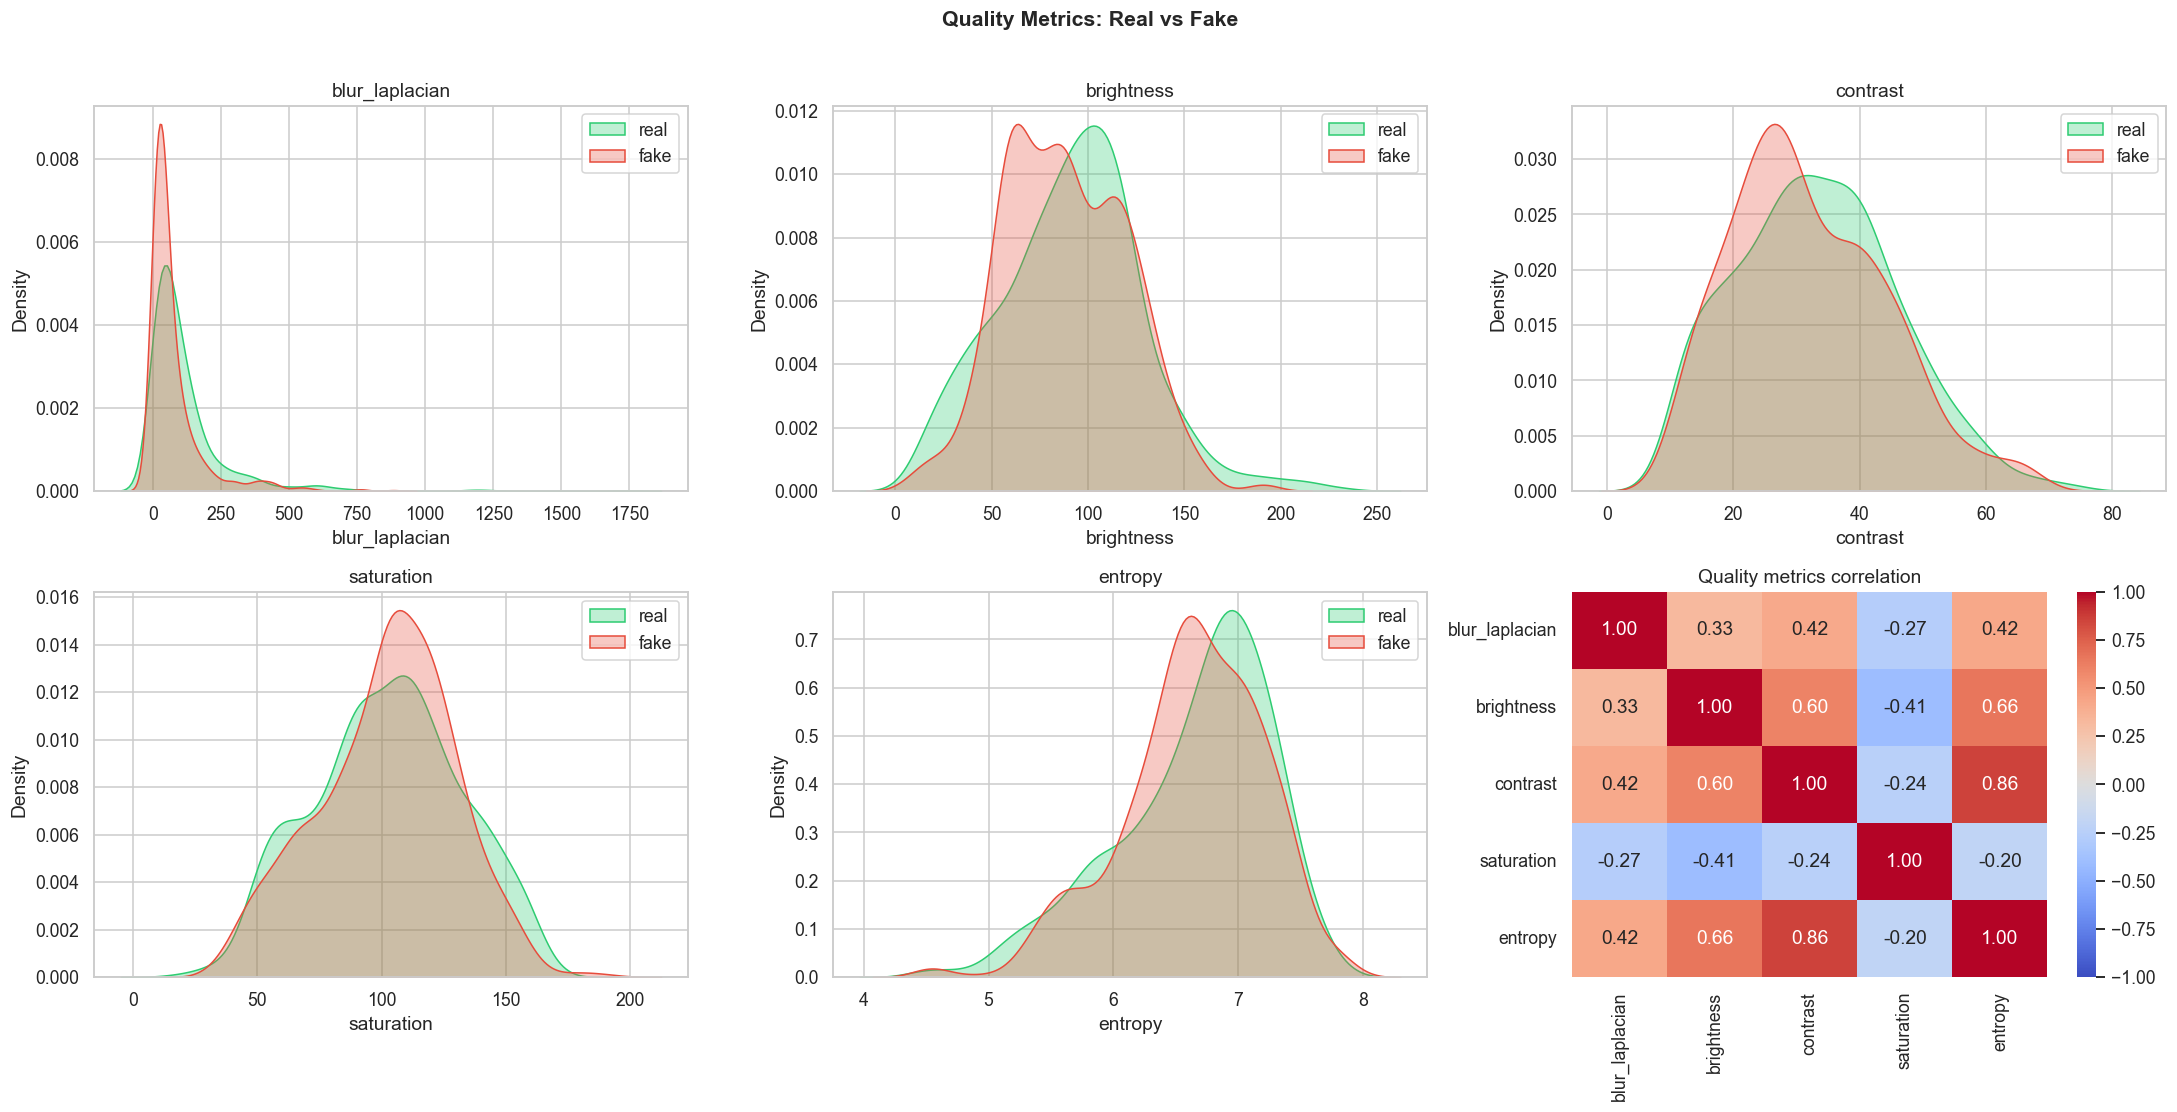


--- Quality Bias Check ---
  blur_laplacian      : real=114.4 fake=74.2 effect_size=0.31 ✓ OK
  brightness          : real=90.9 fake=88.1 effect_size=0.08 ✓ OK
  contrast            : real=33.2 fake=31.9 effect_size=0.11 ✓ OK
  saturation          : real=102.3 fake=102.2 effect_size=0.00 ✓ OK
  entropy             : real=6.6 fake=6.6 effect_size=0.02 ✓ OK

Если effect_size > 0.5: модель может учиться на артефактах качества/источника, а не на deepfake-признаках.


In [49]:
if len(df_quality) > 0:
    qmetrics = ['blur_laplacian', 'brightness', 'contrast', 'saturation', 'entropy']

    # KDE plots: real vs fake.
    fig, axes = plt.subplots(2, 3, figsize=(20, 10))
    axes_flat = axes.flatten()

    for i, col in enumerate(qmetrics):
        ax = axes_flat[i]
        for lab, c in [('real','#2ecc71'),('fake','#e74c3c')]:
            s = df_quality[df_quality['label']==lab][col].dropna()
            if len(s) > 5:
                sns.kdeplot(s, ax=ax, label=lab, color=c, fill=True, alpha=0.3)
        ax.set_title(col)
        ax.legend()

    # Correlation heatmap.
    corr = df_quality[qmetrics].corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes_flat[5],
                vmin=-1, vmax=1)
    axes_flat[5].set_title('Quality metrics correlation')

    plt.suptitle('Quality Metrics: Real vs Fake', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    save_fig("08_quality_metrics")
    plt.show()

    # Bias check: effect size.
    print("\n--- Quality Bias Check ---")
    for col in qmetrics:
        r = df_quality[df_quality['label']=='real'][col].dropna()
        f = df_quality[df_quality['label']=='fake'][col].dropna()
        if len(r) < 5 or len(f) < 5: continue
        d = abs(r.mean() - f.mean())
        pooled = np.sqrt((r.std()**2 + f.std()**2) / 2)
        es = d / pooled if pooled > 0 else 0
        flag = "⚠ BIAS RISK" if es > 0.5 else "✓ OK"
        print(f"  {col:20s}: real={r.mean():.1f} fake={f.mean():.1f} "
              f"effect_size={es:.2f} {flag}")

    print("\nЕсли effect_size > 0.5: модель может учиться на артефактах качества/источника, "
          "а не на deepfake-признаках.")

## 10. Temporal / Sequence-Level Analysis

Ключевой раздел: анализ пригодности **видеоклипов** для temporal branch (T=16).  
Извлекаем кадры из `.mp4`, считаем inter-frame difference, face persistence.


In [52]:
# =====================================================================
# 10. TEMPORAL / SEQUENCE-LEVEL ANALYSIS — VIDEO CLIPS
# =====================================================================

print("=== TEMPORAL ANALYSIS (video clips) ===")

dfv_temporal = df[
    (df["file_type"] == "video") &
    (df["is_readable"])
].copy()

print(f"Video clips available: {len(dfv_temporal)}")

temporal_records = []
N_TEMPORAL_SAMPLE = min(300, len(dfv_temporal))  # sample for speed

if len(dfv_temporal) > 0 and RUN_HEAVY_ANALYSIS:
    temporal_sample = dfv_temporal.sample(N_TEMPORAL_SAMPLE, random_state=RANDOM_SEED)

    for _, row in tqdm(temporal_sample.iterrows(), total=len(temporal_sample),
                       desc="Temporal analysis"):
        frames = extract_frames_uniform(row["path"], n=TARGET_CLIP_LEN)

        if len(frames) < 2:
            continue

        # Inter-frame differences
        diffs = []
        for i in range(len(frames) - 1):
            f1 = frames[i].astype(np.float32)
            f2 = frames[i + 1].astype(np.float32)
            diff = np.mean(np.abs(f2 - f1))
            diffs.append(diff)

        mean_ifd = float(np.mean(diffs)) if diffs else 0.0
        std_ifd = float(np.std(diffs)) if diffs else 0.0
        max_ifd = float(np.max(diffs)) if diffs else 0.0
        min_ifd = float(np.min(diffs)) if diffs else 0.0

        # Face detection on extracted frames
        n_faces_detected = 0
        face_areas = []
        max_continuous_face = 0
        current_streak = 0

        for frame in frames:
            try:
                gray = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
                face_cascade = cv2.CascadeClassifier(
                    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
                )
                faces = face_cascade.detectMultiScale(gray, 1.1, 4, minSize=(20, 20))
                if len(faces) > 0:
                    n_faces_detected += 1
                    current_streak += 1
                    max_continuous_face = max(max_continuous_face, current_streak)
                    # Largest face area ratio
                    areas = [w * h for (x, y, w, h) in faces]
                    img_area = frame.shape[0] * frame.shape[1]
                    face_areas.append(max(areas) / img_area if img_area > 0 else 0)
                else:
                    current_streak = 0
            except Exception:
                current_streak = 0

        n_frames = len(frames)
        face_persistence = n_faces_detected / n_frames if n_frames > 0 else 0.0
        mean_face_area = float(np.mean(face_areas)) if face_areas else 0.0
        is_temporal_ready = (n_frames >= TARGET_CLIP_LEN // 2) and (face_persistence >= MIN_VALID_FACE_RATIO)

        temporal_records.append({
            "sample_id": row.get("sample_id", row.name),
            "path": row["path"],
            "label": row["label"],
            "n_frames_extracted": n_frames,
            "mean_ifd": mean_ifd,
            "std_ifd": std_ifd,
            "max_ifd": max_ifd,
            "min_ifd": min_ifd,
            "face_persistence_ratio": face_persistence,
            "mean_face_area_ratio": mean_face_area,
            "max_continuous_valid_len": max_continuous_face,
            "is_temporal_ready": is_temporal_ready,
        })

df_temporal = pd.DataFrame(temporal_records)
save_csv(df_temporal, "temporal_metrics.csv")

# Clip candidates
if len(df_temporal) > 0:
    df_clip_candidates = df_temporal[df_temporal["is_temporal_ready"]].copy()
    save_csv(df_clip_candidates, "clip_candidates.csv")

mini_report("TEMPORAL ANALYSIS", {
    "Videos analyzed": len(df_temporal),
    "Temporal-ready clips": int(df_temporal["is_temporal_ready"].sum()) if len(df_temporal) > 0 else 0,
    "Mean face persistence": f"{df_temporal['face_persistence_ratio'].mean():.3f}" if len(df_temporal) > 0 else "N/A",
    "Mean IFD": f"{df_temporal['mean_ifd'].mean():.2f}" if len(df_temporal) > 0 else "N/A",
})


=== TEMPORAL ANALYSIS (video clips) ===
Video clips available: 3293


Temporal analysis: 100%|██████████████████████| 300/300 [00:54<00:00,  5.51it/s]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  TEMPORAL ANALYSIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Videos analyzed: 300
  Temporal-ready clips: 46
  Mean face persistence: 0.258
  Mean IFD: 16.99
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━



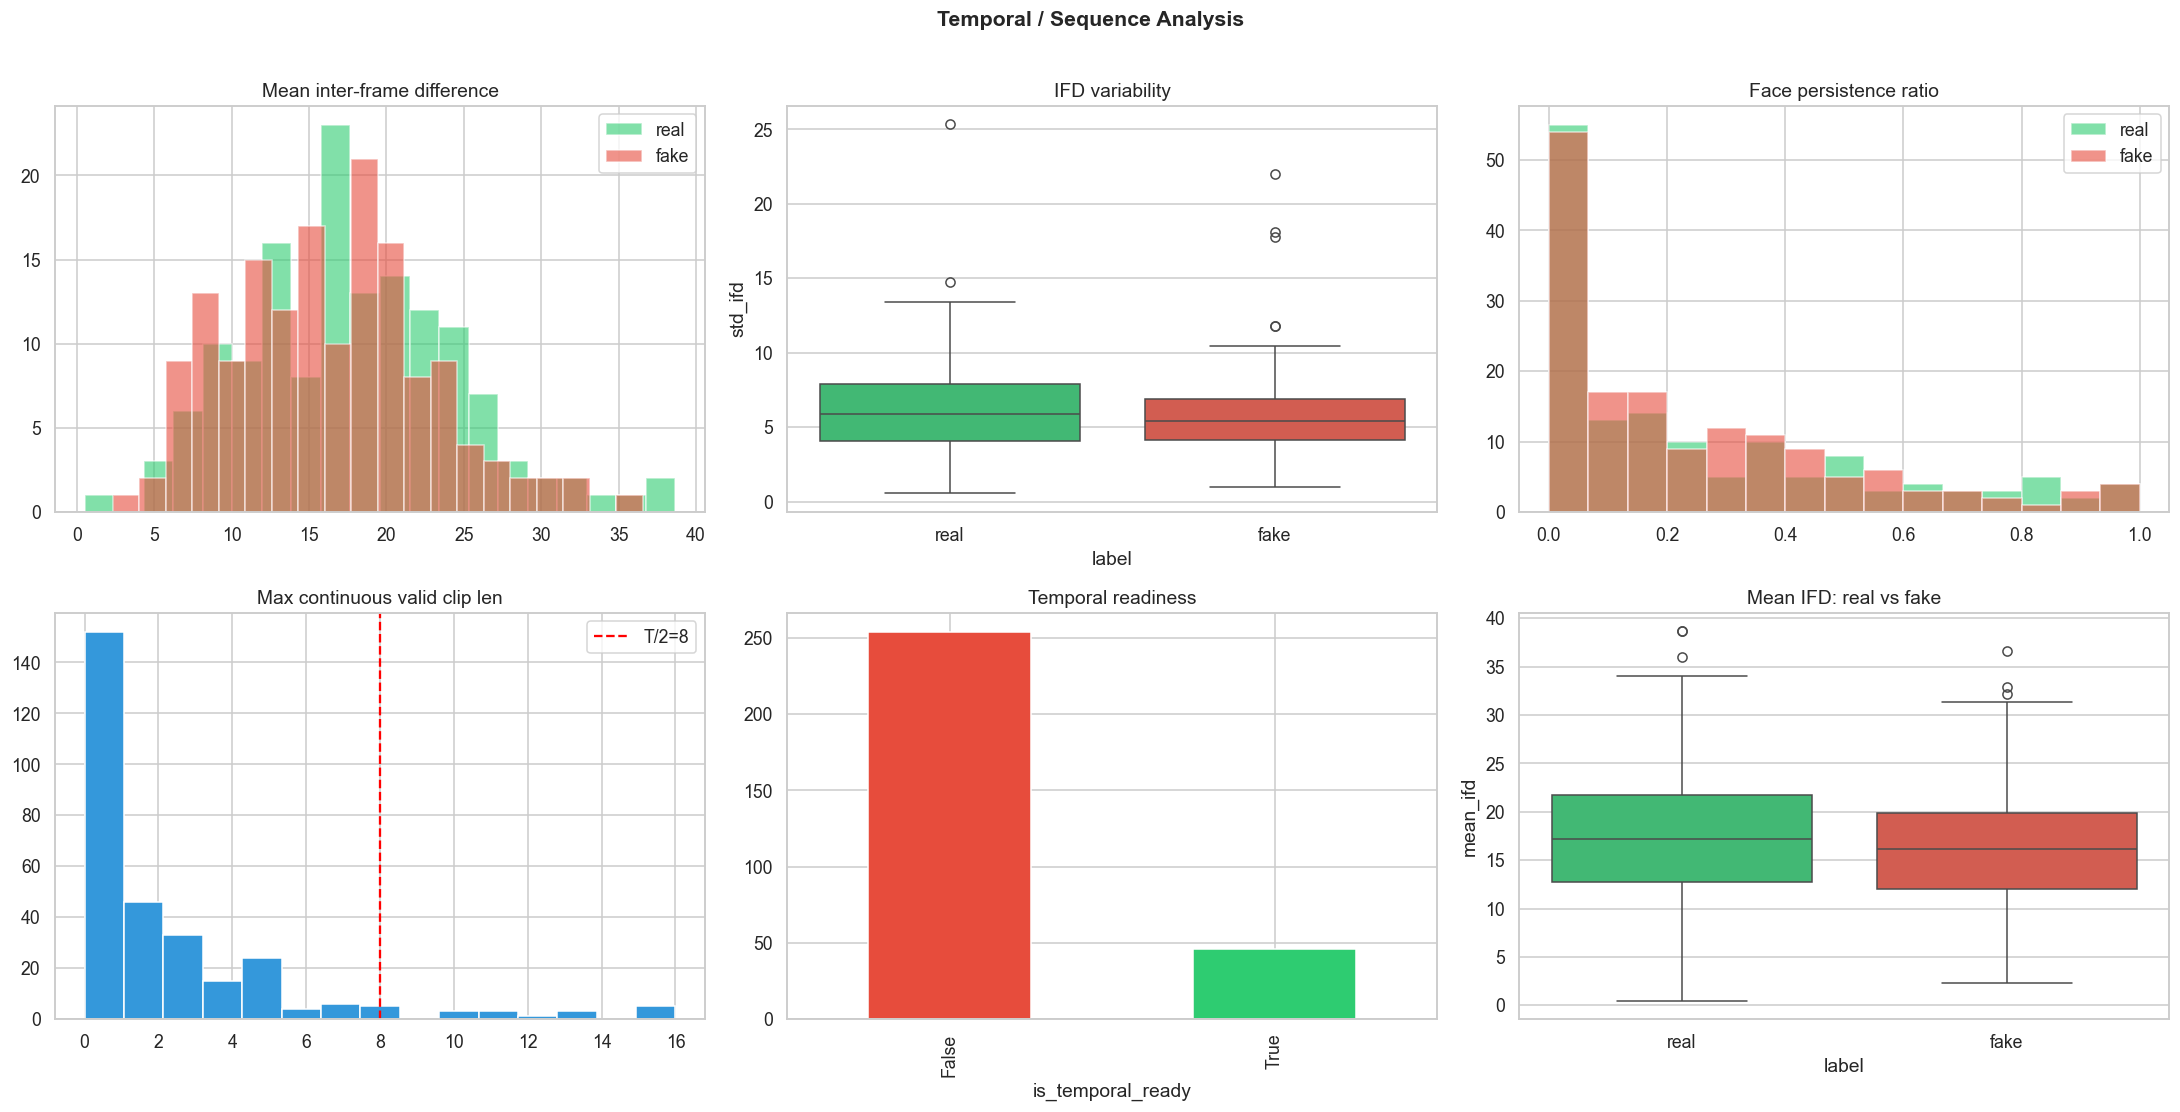


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  TEMPORAL ANALYSIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Sequences analyzed: 300
  Temporal-ready: 46 (15.3%)
  Mean face persistence: 0.258
  Mean IFD (real): 17.7316
  Mean IFD (fake): 16.3012
  Clip candidates: 46
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

→ Разница IFD невелика на уровне среднего; модели нужны более тонкие temporal паттерны.


In [53]:
if len(df_temporal) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(20, 10))

    # Mean IFD by label
    for lab, c in [("real", "#2ecc71"), ("fake", "#e74c3c")]:
        s = df_temporal[df_temporal["label"] == lab]["mean_ifd"].dropna()
        if len(s) > 0:
            axes[0, 0].hist(s, bins=20, alpha=0.6, label=lab, color=c)
    axes[0, 0].set_title("Mean inter-frame difference")
    axes[0, 0].legend()

    # Std IFD
    plot_df = df_temporal[df_temporal["label"].isin(["real", "fake"])].copy()
    if len(plot_df) > 0:
        sns.boxplot(
            data=plot_df,
            x="label",
            y="std_ifd",
            ax=axes[0, 1],
            palette={"real": "#2ecc71", "fake": "#e74c3c"},
        )
    axes[0, 1].set_title("IFD variability")

    # Face persistence
    for lab, c in [("real", "#2ecc71"), ("fake", "#e74c3c")]:
        s = df_temporal[df_temporal["label"] == lab]["face_persistence_ratio"].dropna()
        if len(s) > 0:
            axes[0, 2].hist(s, bins=15, alpha=0.6, label=lab, color=c)
    axes[0, 2].set_title("Face persistence ratio")
    axes[0, 2].legend()

    # Max continuous valid length
    df_temporal["max_continuous_valid_len"].hist(ax=axes[1, 0], bins=15, color="#3498db")
    axes[1, 0].axvline(TARGET_CLIP_LEN // 2, color="red", ls="--", label=f"T/2={TARGET_CLIP_LEN // 2}")
    axes[1, 0].set_title("Max continuous valid clip len")
    axes[1, 0].legend()

    # Temporal readiness
    tr = df_temporal["is_temporal_ready"].value_counts()
    tr.plot.bar(ax=axes[1, 1], color=["#e74c3c", "#2ecc71"])
    axes[1, 1].set_title("Temporal readiness")

    # Mean IFD real vs fake
    if len(plot_df) > 0:
        sns.boxplot(
            data=plot_df,
            x="label",
            y="mean_ifd",
            ax=axes[1, 2],
            palette={"real": "#2ecc71", "fake": "#e74c3c"},
        )
    axes[1, 2].set_title("Mean IFD: real vs fake")

    plt.suptitle("Temporal / Sequence Analysis", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    save_fig("09_temporal_analysis")
    plt.show()

    clip_candidates = df_temporal[df_temporal["is_temporal_ready"]].copy()
    save_csv(clip_candidates, "clip_candidates.csv")

    real_ifd_series = df_temporal[df_temporal["label"] == "real"]["mean_ifd"].dropna()
    fake_ifd_series = df_temporal[df_temporal["label"] == "fake"]["mean_ifd"].dropna()

    mini_report("TEMPORAL ANALYSIS", {
        "Sequences analyzed": len(df_temporal),
        "Temporal-ready": f"{int(df_temporal['is_temporal_ready'].sum())} ({df_temporal['is_temporal_ready'].mean()*100:.1f}%)",
        "Mean face persistence": f"{df_temporal['face_persistence_ratio'].mean():.3f}",
        "Mean IFD (real)": f"{real_ifd_series.mean():.4f}" if len(real_ifd_series) > 0 else "N/A",
        "Mean IFD (fake)": f"{fake_ifd_series.mean():.4f}" if len(fake_ifd_series) > 0 else "N/A",
        "Clip candidates": len(clip_candidates),
    })

    if len(real_ifd_series) > 0 and len(fake_ifd_series) > 0:
        real_ifd = real_ifd_series.mean()
        fake_ifd = fake_ifd_series.mean()

        if abs(real_ifd - fake_ifd) / max(real_ifd, fake_ifd, 0.01) > 0.1:
            print("→ Заметная разница IFD между real и fake: это поддерживает гипотезу о полезности temporal features.")
        else:
            print("→ Разница IFD невелика на уровне среднего; модели нужны более тонкие temporal паттерны.")

## 11. Formal Cleaning Rules

Определяем machine-readable правила очистки. Применяем их. Сохраняем dropped_samples.csv с причиной удаления.

In [55]:
CLEANING_RULES = OrderedDict([
    ("unreadable",       lambda row: not row["is_readable"]),
    ("empty_file",       lambda row: row["size_bytes"] < 1024),
    ("missing_label",    lambda row: row["label"] == "unknown"),
    ("low_resolution",   lambda row: row["is_readable"] and min(row["width"], row["height"]) < MIN_RESOLUTION),
    ("too_short_video",  lambda row: row["file_type"] == "video" and row["duration_sec"] < MIN_DURATION_SEC),
    ("invalid_fps",      lambda row: row["file_type"] == "video" and (
        row["fps"] <= 0 or row["fps"] < VALID_FPS_RANGE[0] or row["fps"] > VALID_FPS_RANGE[1])),
    ("too_few_frames",   lambda row: row["file_type"] == "video" and row["frame_count"] < TARGET_CLIP_LEN),
    ("duplicate_hash",   lambda row: "duplicate_hash" in str(row.get("issue_flags", ""))),
])

print("=== CLEANING RULES ===")
for name in CLEANING_RULES.keys():
    print(f"  • {name}")

dropped_records = []
keep_mask = pd.Series(True, index=df.index)

for rule_name, rule_fn in CLEANING_RULES.items():
    rule_mask = df.apply(rule_fn, axis=1)
    newly_dropped = rule_mask & keep_mask
    n_dropped = int(newly_dropped.sum())

    if n_dropped > 0:
        dropped_chunk = df.loc[newly_dropped, ["sample_id", "path", "source_dataset", "label"]].copy()
        dropped_chunk["drop_stage"] = "cleaning"
        dropped_chunk["drop_reason"] = rule_name
        dropped_chunk["drop_reason_group"] = rule_name.split("_")[0]
        dropped_records.append(dropped_chunk)

    keep_mask = keep_mask & ~rule_mask
    print(f"  {rule_name}: удалено {n_dropped}, осталось {int(keep_mask.sum())}")

df_dropped = pd.concat(dropped_records, ignore_index=True) if dropped_records else pd.DataFrame(
    columns=["sample_id", "path", "source_dataset", "label", "drop_stage", "drop_reason", "drop_reason_group"]
)
df_clean = df.loc[keep_mask].copy()

save_csv(df_dropped, "dropped_samples.csv", CLEAN_DIR)
save_csv(df_clean, "cleaned_metadata.csv", CLEAN_DIR)

print(f"\nИтого: {len(df)} → {len(df_clean)} (удалено {len(df_dropped)})")

=== CLEANING RULES ===
  • unreadable
  • empty_file
  • missing_label
  • low_resolution
  • too_short_video
  • invalid_fps
  • too_few_frames
  • duplicate_hash
  unreadable: удалено 0, осталось 3293
  empty_file: удалено 0, осталось 3293
  missing_label: удалено 0, осталось 3293
  low_resolution: удалено 0, осталось 3293
  too_short_video: удалено 1, осталось 3292
  invalid_fps: удалено 0, осталось 3292
  too_few_frames: удалено 0, осталось 3292
  duplicate_hash: удалено 0, осталось 3292

Итого: 3293 → 3292 (удалено 1)


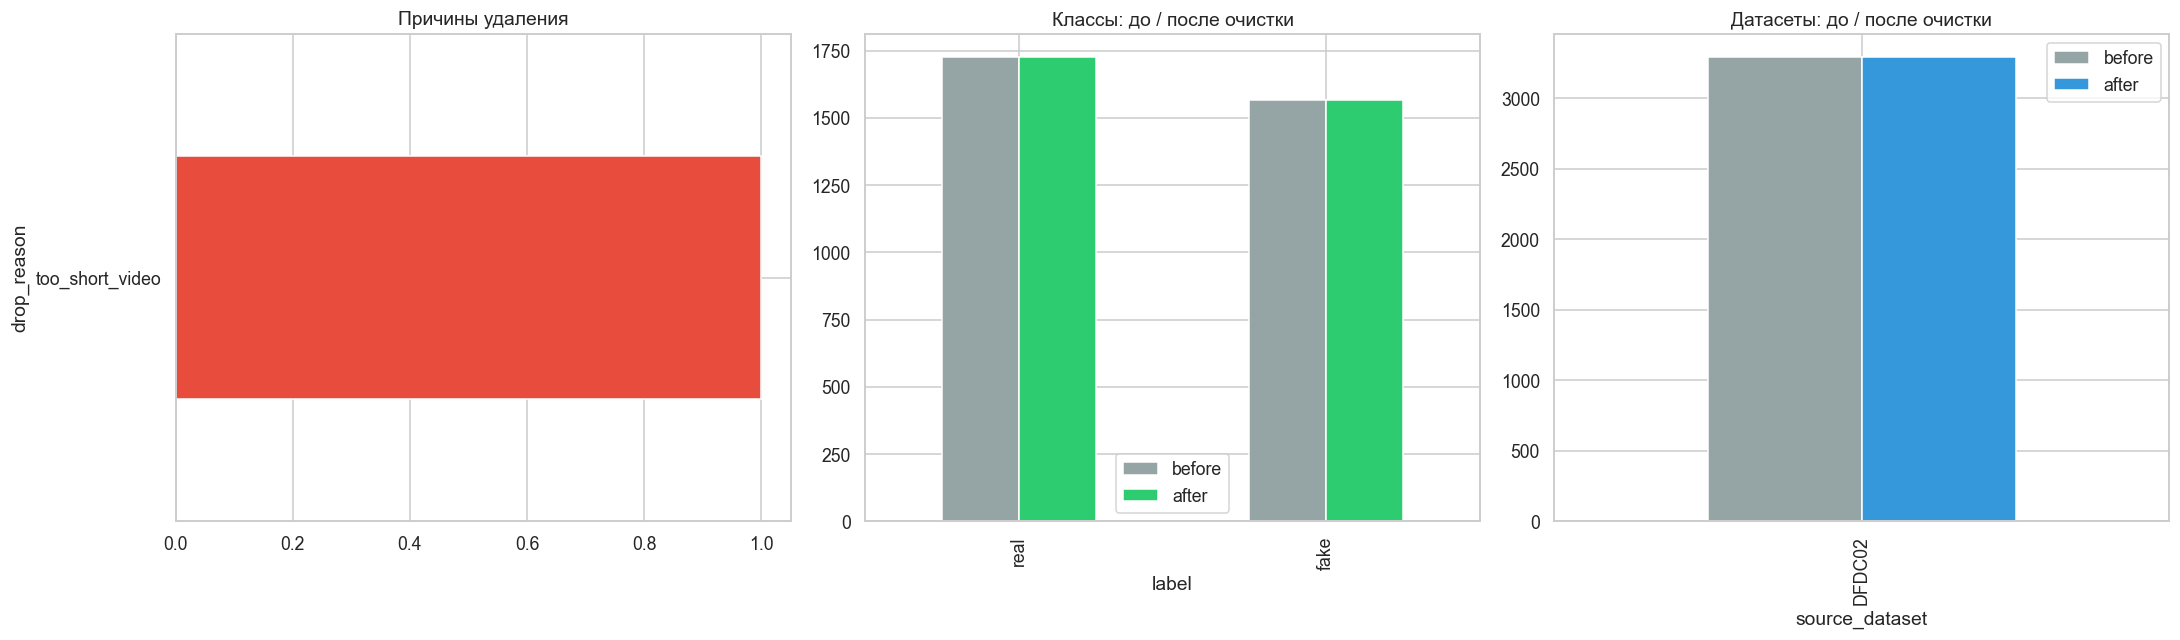

label           raw_fake  raw_real  clean_fake  clean_real
source_dataset                                            
DFDC02              1566      1727        1566        1726


In [56]:
# Визуализация очистки.
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Причины удаления.
if len(df_dropped) > 0:
    df_dropped['drop_reason'].value_counts().plot.barh(ax=axes[0], color='#e74c3c')
    axes[0].set_title('Причины удаления')
    axes[0].invert_yaxis()
else:
    axes[0].text(0.5, 0.5, 'Ничего не удалено', transform=axes[0].transAxes, ha='center')
    axes[0].set_title('Причины удаления')

# 2. До/после по классам.
before = df['label'].value_counts()
after = df_clean['label'].value_counts()
comp = pd.DataFrame({'before': before, 'after': after}).fillna(0)
comp.plot.bar(ax=axes[1], color=['#95a5a6', '#2ecc71'])
axes[1].set_title('Классы: до / после очистки')

# 3. До/после по датасетам.
before_ds = df['source_dataset'].value_counts()
after_ds = df_clean['source_dataset'].value_counts()
comp_ds = pd.DataFrame({'before': before_ds, 'after': after_ds}).fillna(0)
comp_ds.plot.bar(ax=axes[2], color=['#95a5a6', '#3498db'])
axes[2].set_title('Датасеты: до / после очистки')

plt.tight_layout()
save_fig("10_cleaning_effect")
plt.show()

# Raw vs cleaned comparison table.
raw_counts = df.groupby(['source_dataset','label']).size().unstack(fill_value=0)
clean_counts = df_clean.groupby(['source_dataset','label']).size().unstack(fill_value=0)
comparison = pd.concat([raw_counts.add_prefix('raw_'), clean_counts.add_prefix('clean_')], axis=1).fillna(0).astype(int)
save_csv(comparison.reset_index(), "raw_vs_cleaned_comparison.csv", CLEAN_DIR)
print(comparison)

## 12. Cleaned Dataset Summary

Итоговое состояние данных после очистки.

In [58]:
print("=== CLEANED DATASET SUMMARY ===\n")

for ds in df_clean['source_dataset'].unique():
    sub = df_clean[df_clean['source_dataset']==ds]
    print(f"--- {ds} ---")
    print(f"  Total: {len(sub)}")
    print(f"  Real: {len(sub[sub['label']=='real'])}")
    print(f"  Fake: {len(sub[sub['label']=='fake'])}")
    if len(sub) > 0 and 'real' in sub['label'].values and 'fake' in sub['label'].values:
        r = len(sub[sub['label']=='fake']) / max(len(sub[sub['label']=='real']),1)
        print(f"  Fake/Real ratio: {r:.2f}")
    print()

# Temporal readiness (только для видео).
vid_clean = df_clean[df_clean['file_type']=='video']
if len(vid_clean) > 0:
    if len(df_temporal) > 0:
        temporal_ids = set(df_temporal[df_temporal['is_temporal_ready']]['sample_id'])
        n_temporal_ready = vid_clean['sample_id'].isin(temporal_ids).sum()
        print(f"Temporal-ready videos (in cleaned set): {n_temporal_ready} / {len(vid_clean)}")

# Cleaned summary table.
summary_rows = []
for ds in df_clean['source_dataset'].unique():
    sub = df_clean[df_clean['source_dataset']==ds]
    summary_rows.append({
        'dataset': ds,
        'total': len(sub),
        'real': len(sub[sub['label']=='real']),
        'fake': len(sub[sub['label']=='fake']),
        'images': len(sub[sub['file_type']=='image']),
        'videos': len(sub[sub['file_type']=='video']),
    })
df_clean_summary = pd.DataFrame(summary_rows)
save_csv(df_clean_summary, "cleaned_summary_tables.csv", CLEAN_DIR)
print(df_clean_summary.to_string(index=False))

=== CLEANED DATASET SUMMARY ===

--- DFDC02 ---
  Total: 3292
  Real: 1726
  Fake: 1566
  Fake/Real ratio: 0.91

Temporal-ready videos (in cleaned set): 46 / 3292
dataset  total  real  fake  images  videos
 DFDC02   3292  1726  1566       0    3292


## 13. Preprocessing Pipeline & Train/Val/Test Manifests

Генерируем manifest-файлы для обучения. Split по group_id (leakage-safe). Stratified по label.

In [60]:
# === Preprocessing config ===
PREPROCESS_CONFIG = {
    'clip_length': TARGET_CLIP_LEN,
    'spatial_size': 224,
    'temporal_size': 128,
    'face_crop': 'MTCNN (facenet-pytorch)',
    'spatial_norm': 'ImageNet mean/std',
    'temporal_input': 'frame differences (T-1)',
    'temporal_norm': 'zero-center + unit variance per clip',
    'sampling': 'uniform',
    'augmentation': 'HFlip, brightness±0.1, contrast±0.1 (train only)',
}

print("=== PREPROCESSING CONFIG ===")
for k, v in PREPROCESS_CONFIG.items():
    print(f"  {k}: {v}")

=== PREPROCESSING CONFIG ===
  clip_length: 16
  spatial_size: 224
  temporal_size: 128
  face_crop: MTCNN (facenet-pytorch)
  spatial_norm: ImageNet mean/std
  temporal_input: frame differences (T-1)
  temporal_norm: zero-center + unit variance per clip
  sampling: uniform
  augmentation: HFlip, brightness±0.1, contrast±0.1 (train only)


In [70]:
print(df_temporal.columns.tolist())

['sample_id', 'path', 'label', 'n_frames_extracted', 'mean_ifd', 'std_ifd', 'max_ifd', 'min_ifd', 'face_persistence_ratio', 'mean_face_area_ratio', 'max_continuous_valid_len', 'is_temporal_ready']


In [72]:
# === Split generation ===
# Используем DFDC02 (primary) для train/val/test.
# secondary — отдельно для auxiliary / cross evaluation.

df_for_split = df_clean[df_clean["source_dataset"] == DATASET_NAME].copy()
df_cross = df_clean[df_clean["source_dataset"] != DATASET_NAME].copy()

print(f"Для split: {len(df_for_split)} samples ({DATASET_NAME})")
print(f"Для cross/raw-video eval: {len(df_cross)} samples (secondary)")

if len(df_for_split) == 0:
    print("[ОШИБКА] Нет данных для split!")
else:
    rng = np.random.RandomState(RANDOM_SEED)

    group_labels = (
        df_for_split.groupby("group_id")["label"]
        .first()
        .reset_index()
    )

    manifests = {"train": [], "val": [], "test": []}

    for label_val in ["real", "fake"]:
        groups = group_labels[group_labels["label"] == label_val]["group_id"].values.copy()
        rng.shuffle(groups)

        n = len(groups)
        n_train = int(n * 0.70)
        n_val = int(n * 0.15)

        train_groups = set(groups[:n_train])
        val_groups = set(groups[n_train:n_train + n_val])
        test_groups = set(groups[n_train + n_val:])

        manifests["train"].extend(df_for_split[df_for_split["group_id"].isin(train_groups)].index.tolist())
        manifests["val"].extend(df_for_split[df_for_split["group_id"].isin(val_groups)].index.tolist())
        manifests["test"].extend(df_for_split[df_for_split["group_id"].isin(test_groups)].index.tolist())

    if len(face_video_summary) > 0:
        face_dict = face_video_summary.set_index("sample_id")[
            ["face_detection_ratio", "mean_face_area_ratio", "multi_face_ratio", "no_face_ratio"]
        ].to_dict("index")

        df_for_split["face_detection_ratio"] = df_for_split["sample_id"].map(
            lambda x: face_dict.get(x, {}).get("face_detection_ratio", np.nan)
        )
        df_for_split["mean_face_area_ratio"] = df_for_split["sample_id"].map(
            lambda x: face_dict.get(x, {}).get("mean_face_area_ratio", np.nan)
        )
        df_for_split["multi_face_ratio"] = df_for_split["sample_id"].map(
            lambda x: face_dict.get(x, {}).get("multi_face_ratio", np.nan)
        )
        df_for_split["no_face_ratio"] = df_for_split["sample_id"].map(
            lambda x: face_dict.get(x, {}).get("no_face_ratio", np.nan)
        )

    if len(df_temporal) > 0:
        temporal_key = "group_id" if "group_id" in df_temporal.columns else "sample_id"
        split_key = "group_id" if temporal_key == "group_id" else "sample_id"

        temporal_dict = df_temporal.set_index(temporal_key)[
            ["is_temporal_ready", "face_persistence_ratio", "max_continuous_valid_len", "mean_ifd"]
        ].to_dict("index")

        df_for_split["is_temporal_ready"] = df_for_split[split_key].map(
            lambda x: temporal_dict.get(x, {}).get("is_temporal_ready", np.nan)
        )
        df_for_split["face_persistence_ratio"] = df_for_split[split_key].map(
            lambda x: temporal_dict.get(x, {}).get("face_persistence_ratio", np.nan)
        )
        df_for_split["max_continuous_valid_len"] = df_for_split[split_key].map(
            lambda x: temporal_dict.get(x, {}).get("max_continuous_valid_len", np.nan)
        )
        df_for_split["mean_ifd"] = df_for_split[split_key].map(
            lambda x: temporal_dict.get(x, {}).get("mean_ifd", np.nan)
        )

    manifest_cols = [
        "sample_id",
        "path",
        "label",
        "label_int",
        "source_dataset",
        "group_id",
        "file_type",
        "width",
        "height",
        "fps",
        "duration_sec",
        "aspect_ratio",
        "face_detection_ratio",
        "mean_face_area_ratio",
        "multi_face_ratio",
        "no_face_ratio",
        "is_temporal_ready",
        "face_persistence_ratio",
        "max_continuous_valid_len",
        "mean_ifd",
    ]

    split_dfs = {}

    for split_name, indices in manifests.items():
        m = df_for_split.loc[indices].copy()
        m["group_id_for_split"] = m["group_id"]
        m["split"] = split_name

        available_cols = [c for c in manifest_cols if c in m.columns]
        m = m[available_cols + ["group_id_for_split", "split"]]

        save_csv(m, f"{split_name}_manifest.csv", MANIFESTS_DIR)
        split_dfs[split_name] = m

        print(
            f"  {split_name}: {len(m)} samples "
            f"(real={len(m[m['label']=='real'])}, fake={len(m[m['label']=='fake'])})"
        )

    train_ids = set(split_dfs["train"]["sample_id"]) if "train" in split_dfs else set()
    val_ids = set(split_dfs["val"]["sample_id"]) if "val" in split_dfs else set()
    test_ids = set(split_dfs["test"]["sample_id"]) if "test" in split_dfs else set()

    assert train_ids.isdisjoint(val_ids), "train/val overlap detected"
    assert train_ids.isdisjoint(test_ids), "train/test overlap detected"
    assert val_ids.isdisjoint(test_ids), "val/test overlap detected"

    train_groups = set(split_dfs["train"]["group_id_for_split"]) if "train" in split_dfs else set()
    val_groups = set(split_dfs["val"]["group_id_for_split"]) if "val" in split_dfs else set()
    test_groups = set(split_dfs["test"]["group_id_for_split"]) if "test" in split_dfs else set()

    assert train_groups.isdisjoint(val_groups), "train/val group leakage detected"
    assert train_groups.isdisjoint(test_groups), "train/test group leakage detected"
    assert val_groups.isdisjoint(test_groups), "val/test group leakage detected"

    print("Split sanity checks: OK")

    if len(df_cross) > 0:
        df_cross_m = df_cross.copy()
        df_cross_m["group_id_for_split"] = df_cross_m["group_id"]
        df_cross_m["split"] = "cross_eval"

        available_cols = [c for c in manifest_cols if c in df_cross_m.columns]
        df_cross_m = df_cross_m[available_cols + ["group_id_for_split", "split"]]

        save_csv(df_cross_m, "cross_eval_manifest.csv", MANIFESTS_DIR)
        print(f"  cross_eval: {len(df_cross_m)} samples")

Для split: 3292 samples (DFDC02)
Для cross/raw-video eval: 0 samples (secondary)
  train: 2304 samples (real=1208, fake=1096)
  val: 492 samples (real=258, fake=234)
  test: 496 samples (real=260, fake=236)
Split sanity checks: OK


In [74]:
# === Leakage sanity check ===
print("\n=== LEAKAGE SANITY CHECK ===")

train_m = pd.read_csv(Path(MANIFESTS_DIR) / "train_manifest.csv")
val_m   = pd.read_csv(Path(MANIFESTS_DIR) / "val_manifest.csv")
test_m  = pd.read_csv(Path(MANIFESTS_DIR) / "test_manifest.csv")

train_groups = set(train_m["group_id_for_split"])
val_groups   = set(val_m["group_id_for_split"])
test_groups  = set(test_m["group_id_for_split"])

tv_overlap = train_groups & val_groups
tt_overlap = train_groups & test_groups
vt_overlap = val_groups & test_groups

print(f"  train ∩ val:  {len(tv_overlap)} groups {'✓ OK' if len(tv_overlap) == 0 else '⚠ LEAKAGE!'}")
print(f"  train ∩ test: {len(tt_overlap)} groups {'✓ OK' if len(tt_overlap) == 0 else '⚠ LEAKAGE!'}")
print(f"  val ∩ test:   {len(vt_overlap)} groups {'✓ OK' if len(vt_overlap) == 0 else '⚠ LEAKAGE!'}")

if len(tv_overlap) + len(tt_overlap) + len(vt_overlap) == 0:
    print("  ✓ NO LEAKAGE DETECTED")
else:
    print("  ⚠ LEAKAGE DETECTED — FIX SPLIT LOGIC")


=== LEAKAGE SANITY CHECK ===
  train ∩ val:  0 groups ✓ OK
  train ∩ test: 0 groups ✓ OK
  val ∩ test:   0 groups ✓ OK
  ✓ NO LEAKAGE DETECTED


## 14. Post-preprocessing EDA

Финальная проверка train/val/test split: баланс, распределения, sanity checks.

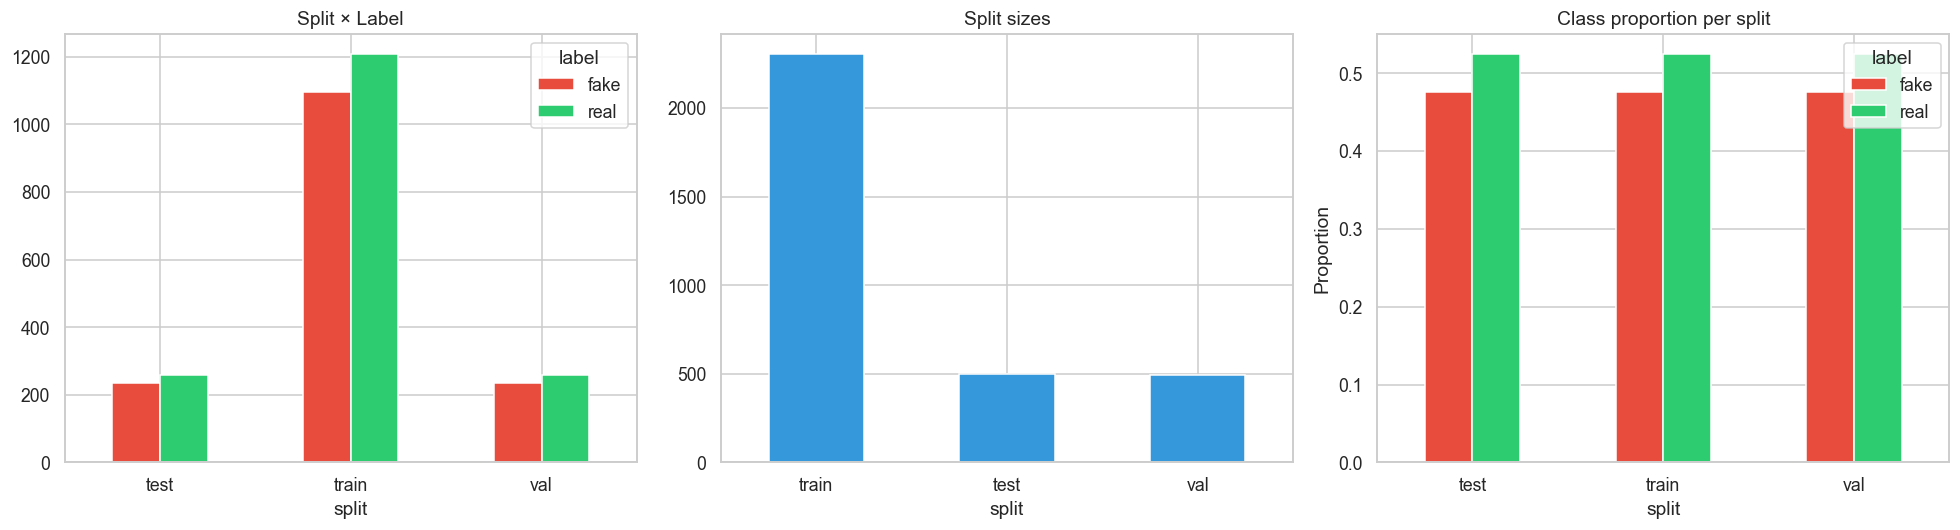

split  total  real  fake  fake_ratio
 test    496   260   236       0.476
train   2304  1208  1096       0.476
  val    492   258   234       0.476

label  fake  real   All
split                  
test    236   260   496
train  1096  1208  2304
val     234   258   492
All    1566  1726  3292


In [77]:
# Объединяем все manifests.
all_manifests = pd.concat([train_m, val_m, test_m], ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Split × label.
ct = pd.crosstab(all_manifests['split'], all_manifests['label'])
ct.plot.bar(ax=axes[0], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Split × Label')
axes[0].tick_params(axis='x', rotation=0)

# 2. Split sizes.
all_manifests['split'].value_counts().plot.bar(ax=axes[1], color='#3498db')
axes[1].set_title('Split sizes')
axes[1].tick_params(axis='x', rotation=0)

# 3. Class balance per split.
balance = all_manifests.groupby('split')['label'].value_counts(normalize=True).unstack()
balance.plot.bar(ax=axes[2], color=['#e74c3c', '#2ecc71'])
axes[2].set_title('Class proportion per split')
axes[2].set_ylabel('Proportion')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
save_fig("11_split_eda")
plt.show()

# Split summary table.
split_summary = all_manifests.groupby('split').agg(
    total=('sample_id', 'count'),
    real=('label', lambda x: (x=='real').sum()),
    fake=('label', lambda x: (x=='fake').sum()),
).reset_index()
split_summary['fake_ratio'] = (split_summary['fake'] / split_summary['total']).round(3)
save_csv(split_summary, "split_summary.csv", MANIFESTS_DIR)
print(split_summary.to_string(index=False))

# Balance table.
balance_tbl = pd.crosstab(all_manifests['split'], all_manifests['label'], margins=True)
save_csv(balance_tbl.reset_index(), "split_balance_tables.csv", MANIFESTS_DIR)
print(f"\n{balance_tbl}")

## 15. Final Analytical Report

In [80]:
print("=" * 70)
print("  ФИНАЛЬНЫЙ АНАЛИТИЧЕСКИЙ ОТЧЁТ")
print("=" * 70)

total_raw = len(df)
total_clean = len(df_clean)
total_dropped = len(df_dropped)
n_videos = int((df["file_type"] == "video").sum())
n_images = int((df["file_type"] == "image").sum())
n_real = int((df["label"] == "real").sum())
n_fake = int((df["label"] == "fake").sum())

report = f"""
1. DATASET: {DATASET_NAME}
   Тип: normalized video clips (112×112, ~30fps, ~5sec)
   Всего clips: {total_raw}
   Videos: {n_videos} | Images: {n_images}
   Real: {n_real} | Fake: {n_fake}
   Balance ratio (fake/real): {n_fake/n_real:.2f}:1

2. QUALITY
   Удалено при очистке: {total_dropped}
"""

if len(df_dropped) > 0:
    for reason, cnt in df_dropped["drop_reason"].value_counts().head(5).items():
        report += f"   • {reason}: {cnt}\n"

report += f"""
3. LEAKAGE
   Split key: group_id (file-level)
   group_id unique per sample: {"Yes" if df["group_id"].nunique() == len(df) else "No"}
"""

report += f"""
4. FACE ANALYSIS
"""
if "face_video_summary" in dir() and len(face_video_summary) > 0:
    report += f"   Face det. rate (mean): {face_video_summary['face_detection_ratio'].mean():.3f}\n"
    report += f"   Samples failing threshold: {int((face_video_summary['face_detection_ratio'] < MIN_VALID_FACE_RATIO).sum())}\n"
else:
    report += "   (skipped)\n"

report += f"""
5. TEMPORAL READINESS
"""
if len(df_temporal) > 0:
    report += f"   Analyzed: {len(df_temporal)} clips\n"
    report += f"   Temporal-ready: {int(df_temporal['is_temporal_ready'].sum())} / {len(df_temporal)}\n"
    report += f"   Mean face persistence: {df_temporal['face_persistence_ratio'].mean():.3f}\n"
    report += f"   Mean IFD: {df_temporal['mean_ifd'].mean():.2f}\n"
else:
    report += "   (skipped)\n"

report += f"""
6. CLEANED DATASET
   Total clean: {total_clean}
"""

if "train_m" in dir():
    report += f"""
7. SPLIT
   Train: {len(train_m)} | Val: {len(val_m)} | Test: {len(test_m)}
"""

report += f"""
8. PREPROCESSING CONFIG
   Face detection (training pipeline): MTCNN (facenet-pytorch)
   Face detection (EDA audit): Haar Cascade (conservative estimate)
   Clip length: T={TARGET_CLIP_LEN}
"""

print(report)

# Save report
report_path = REPORTS_DIR / "final_analytical_report.txt"
report_path.write_text(report, encoding="utf-8")
print(f"Saved: {report_path}")


  ФИНАЛЬНЫЙ АНАЛИТИЧЕСКИЙ ОТЧЁТ

1. DATASET: DFDC02
   Тип: normalized video clips (112×112, ~30fps, ~5sec)
   Всего clips: 3293
   Videos: 3293 | Images: 0
   Real: 1727 | Fake: 1566
   Balance ratio (fake/real): 0.91:1

2. QUALITY
   Удалено при очистке: 1
   • too_short_video: 1

3. LEAKAGE
   Split key: group_id (file-level)
   group_id unique per sample: Yes

4. FACE ANALYSIS
   Face det. rate (mean): 0.224
   Samples failing threshold: 442

5. TEMPORAL READINESS
   Analyzed: 300 clips
   Temporal-ready: 46 / 300
   Mean face persistence: 0.258
   Mean IFD: 16.99

6. CLEANED DATASET
   Total clean: 3292

7. SPLIT
   Train: 2304 | Val: 492 | Test: 496

8. PREPROCESSING CONFIG
   Face detection (training pipeline): MTCNN (facenet-pytorch)
   Face detection (EDA audit): Haar Cascade (conservative estimate)
   Clip length: T=16

Saved: /Users/alext/Desktop/MIFI 3/VKR_Final/Final_Project_deefake_detection/EDA/reports_final/final_analytical_report.txt


## 16. Checklist Before Modeling

| # | Пункт | Статус |
|---|-------|--------|
| 1 | Raw inventory completed | ✅ `master_raw_inventory.csv` |
| 2 | Quality issues registered | ✅ `problem_registry.csv` |
| 3 | Duplicates checked (hash + name) | ✅ |
| 4 | Leakage groups identified | ✅ `leakage_groups.csv` |
| 5 | Face detection coverage measured | ✅ `face_video_summary.csv` |
| 6 | Frame quality metrics computed | ✅ `frame_quality_metrics.csv` |
| 7 | Temporal readiness measured | ✅ `temporal_metrics.csv` |
| 8 | Cleaning rules applied | ✅ `dropped_samples.csv` |
| 9 | Cleaned metadata saved | ✅ `cleaned_metadata.csv` |
| 10 | Train/val/test manifests saved | ✅ `train/val/test_manifest.csv` |
| 11 | Split leakage sanity check passed | ✅ |
| 12 | Dataset ready for baseline training | ✅ |

**Все артефакты сохранены в `reports/`.**

**Следующий шаг:** запуск `train.py` с указанием на manifests.

In [83]:
# Финальная проверка артефактов
print("=== ARTIFACT CHECK ===")

expected = [
    ("tables", "master_raw_inventory.csv"),
    ("tables", "inventory_errors.csv"),
    ("tables", "unsupported_files.csv"),
    ("tables", "dataset_label_crosstab.csv"),
    ("tables", "summary_video_stats.csv"),
    ("tables", "problem_registry.csv"),
    ("tables", "quality_issue_summary.csv"),
    ("tables", "leakage_candidates.csv"),
    ("tables", "leakage_groups.csv"),
    ("tables", "frame_samples_metadata.csv"),
    ("tables", "temporal_metrics.csv"),
    ("tables", "clip_candidates.csv"),
    ("cleaned", "dropped_samples.csv"),
    ("cleaned", "cleaned_metadata.csv"),
    ("manifests", "train_manifest.csv"),
    ("manifests", "val_manifest.csv"),
    ("manifests", "test_manifest.csv"),
]

optional = [
    ("tables", "face_detections.csv"),
    ("tables", "face_video_summary.csv"),
    ("tables", "frame_quality_metrics.csv"),
    ("tables", "face_quality_metrics.csv"),
]

dirs_map = {"tables": TABLES_DIR, "cleaned": CLEAN_DIR, "manifests": MANIFESTS_DIR}

found = missing = 0
for subdir, fname in expected:
    fpath = Path(dirs_map[subdir]) / fname
    exists = fpath.is_file()
    status = "✅" if exists else "❌"
    found += int(exists)
    missing += int(not exists)
    print(f"  {status} {subdir}/{fname}")

print(f"\nExpected: {found}/{found + missing}")

print("\n--- Optional ---")
for subdir, fname in optional:
    fpath = Path(dirs_map[subdir]) / fname
    status = "✅" if fpath.is_file() else "⬜"
    print(f"  {status} {subdir}/{fname}")


=== ARTIFACT CHECK ===
  ✅ tables/master_raw_inventory.csv
  ✅ tables/inventory_errors.csv
  ✅ tables/unsupported_files.csv
  ✅ tables/dataset_label_crosstab.csv
  ✅ tables/summary_video_stats.csv
  ✅ tables/problem_registry.csv
  ✅ tables/quality_issue_summary.csv
  ✅ tables/leakage_candidates.csv
  ✅ tables/leakage_groups.csv
  ✅ tables/frame_samples_metadata.csv
  ✅ tables/temporal_metrics.csv
  ✅ tables/clip_candidates.csv
  ✅ cleaned/dropped_samples.csv
  ✅ cleaned/cleaned_metadata.csv
  ✅ manifests/train_manifest.csv
  ✅ manifests/val_manifest.csv
  ✅ manifests/test_manifest.csv

Expected: 17/17

--- Optional ---
  ✅ tables/face_detections.csv
  ✅ tables/face_video_summary.csv
  ✅ tables/frame_quality_metrics.csv
  ✅ tables/face_quality_metrics.csv


In [85]:
print(df["file_type"].value_counts(dropna=False))
print(df["source_dataset"].value_counts(dropna=False))
print(df[df["source_dataset"].str.contains("DFD", case=False, na=False)][["path", "file_type"]].head(20))

file_type
video    3293
Name: count, dtype: int64
source_dataset
DFDC02    3293
Name: count, dtype: int64
                                                 path file_type
0   /Users/alext/Desktop/MIFI 3/VKR_Final/Final_Pr...     video
1   /Users/alext/Desktop/MIFI 3/VKR_Final/Final_Pr...     video
2   /Users/alext/Desktop/MIFI 3/VKR_Final/Final_Pr...     video
3   /Users/alext/Desktop/MIFI 3/VKR_Final/Final_Pr...     video
4   /Users/alext/Desktop/MIFI 3/VKR_Final/Final_Pr...     video
5   /Users/alext/Desktop/MIFI 3/VKR_Final/Final_Pr...     video
6   /Users/alext/Desktop/MIFI 3/VKR_Final/Final_Pr...     video
7   /Users/alext/Desktop/MIFI 3/VKR_Final/Final_Pr...     video
8   /Users/alext/Desktop/MIFI 3/VKR_Final/Final_Pr...     video
9   /Users/alext/Desktop/MIFI 3/VKR_Final/Final_Pr...     video
10  /Users/alext/Desktop/MIFI 3/VKR_Final/Final_Pr...     video
11  /Users/alext/Desktop/MIFI 3/VKR_Final/Final_Pr...     video
12  /Users/alext/Desktop/MIFI 3/VKR_Final/Final_Pr...     vide

In [87]:
print("DATASET_ROOT =", DATASET_ROOT)
print("DATASET_NAME =", DATASET_NAME)

sample_files = list(Path(DATASET_ROOT).rglob("*"))
sample_files = [p for p in sample_files if p.is_file()][:20]

print(f"\n--- Sample files ({len(sample_files)} shown) ---")
for p in sample_files[:10]:
    print(p)


DATASET_ROOT = /Users/alext/Desktop/MIFI 3/VKR_Final/Final_Project_deefake_detection/data/DFDC_Dataset_02
DATASET_NAME = DFDC02

--- Sample files (20 shown) ---
/Users/alext/Desktop/MIFI 3/VKR_Final/Final_Project_deefake_detection/data/DFDC_Dataset_02/.DS_Store
/Users/alext/Desktop/MIFI 3/VKR_Final/Final_Project_deefake_detection/data/DFDC_Dataset_02/Real/sobblmyurt.mp4
/Users/alext/Desktop/MIFI 3/VKR_Final/Final_Project_deefake_detection/data/DFDC_Dataset_02/Real/pgybuuxxip.mp4
/Users/alext/Desktop/MIFI 3/VKR_Final/Final_Project_deefake_detection/data/DFDC_Dataset_02/Real/sfsayjgzrh.mp4
/Users/alext/Desktop/MIFI 3/VKR_Final/Final_Project_deefake_detection/data/DFDC_Dataset_02/Real/jgdrcvviil.mp4
/Users/alext/Desktop/MIFI 3/VKR_Final/Final_Project_deefake_detection/data/DFDC_Dataset_02/Real/ckrafhjqpz.mp4
/Users/alext/Desktop/MIFI 3/VKR_Final/Final_Project_deefake_detection/data/DFDC_Dataset_02/Real/novarhxpbj.mp4
/Users/alext/Desktop/MIFI 3/VKR_Final/Final_Project_deefake_detection/da

In [89]:
# =====================================================================
# EXPORT ONE DOCUMENT (SAVE INTO PROJECT ROOT) + PDF
# =====================================================================

import os
import json
import base64
import html
from pathlib import Path
from datetime import datetime

# Сохраняем РЯДОМ С ПРОЕКТОМ
EXPORT_DIR = REPORTS_DIR
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

HTML_REPORT_PATH = EXPORT_DIR / "FULL_EDA_REPORT.html"
PDF_REPORT_PATH = EXPORT_DIR / "FULL_EDA_REPORT.pdf"

def img_to_base64(path: Path) -> str:
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")

def safe_read_text(path: Path, max_chars: int = 120000) -> str:
    if not path.exists():
        return ""
    txt = path.read_text(encoding="utf-8", errors="ignore")
    if len(txt) > max_chars:
        txt = txt[:max_chars] + "\n\n...[truncated]..."
    return txt

generated_at = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

summary = {
    "generated_at": generated_at,
    "project_root": str(PROJECT_ROOT),
    "reports_dir": str(REPORTS_DIR),
    "total_raw": int(len(df)) if "df" in globals() else 0,
    "total_clean": int(len(df_clean)) if "df_clean" in globals() else 0,
    "total_dropped": int(len(df_dropped)) if "df_dropped" in globals() else 0,
    "images_raw": int((df["file_type"] == "image").sum()) if "df" in globals() and "file_type" in df.columns else 0,
    "videos_raw": int((df["file_type"] == "video").sum()) if "df" in globals() and "file_type" in df.columns else 0,
    "source_dataset_counts": df["source_dataset"].value_counts().to_dict() if "df" in globals() and "source_dataset" in df.columns else {},
    "file_type_counts": df["file_type"].value_counts().to_dict() if "df" in globals() and "file_type" in df.columns else {},
    "split_sizes": {
        "train": int(len(train_m)) if "train_m" in globals() else 0,
        "val": int(len(val_m)) if "val_m" in globals() else 0,
        "test": int(len(test_m)) if "test_m" in globals() else 0,
    },
    "temporal_sequences": int(len(df_temporal)) if "df_temporal" in globals() else 0,
    "clip_candidates": int(len(clip_candidates)) if "clip_candidates" in globals() else 0,
}

final_report_text = safe_read_text(Path(REPORTS_DIR) / "final_analytical_report.txt")
plot_files = sorted([p for p in Path(PLOTS_DIR).glob("*.png") if p.is_file()])

# -----------------------------
# HTML
# -----------------------------
html_parts = []
html_parts.append(f"""
<!DOCTYPE html>
<html lang="ru">
<head>
<meta charset="UTF-8">
<title>FULL EDA REPORT</title>
<style>
body {{
    font-family: Arial, sans-serif;
    margin: 24px;
    line-height: 1.45;
    color: #222;
}}
h1, h2, h3 {{
    margin-top: 28px;
}}
pre {{
    background: #f5f5f5;
    padding: 12px;
    border-radius: 8px;
    overflow-x: auto;
    white-space: pre-wrap;
}}
img {{
    max-width: 100%;
    border: 1px solid #ddd;
    border-radius: 6px;
    margin: 10px 0 24px 0;
}}
</style>
</head>
<body>
<h1>FULL EDA REPORT</h1>
<p><b>Generated:</b> {html.escape(generated_at)}</p>
<p><b>Project root:</b> {html.escape(str(PROJECT_ROOT))}</p>

<h2>1. Run Summary</h2>
<pre>{html.escape(json.dumps(summary, ensure_ascii=False, indent=2))}</pre>

<h2>2. Final Analytical Report</h2>
<pre>{html.escape(final_report_text if final_report_text else "No final analytical report found")}</pre>

<h2>3. Plots</h2>
""")

if plot_files:
    for p in plot_files:
        b64 = img_to_base64(p)
        html_parts.append(f"""
        <h3>{html.escape(p.name)}</h3>
        <img src="data:image/png;base64,{b64}" alt="{html.escape(p.name)}">
        """)
else:
    html_parts.append("<p>No plots found.</p>")

html_parts.append("</body></html>")
HTML_REPORT_PATH.write_text("".join(html_parts), encoding="utf-8")

# -----------------------------
# PDF
# -----------------------------
from reportlab.lib.pagesizes import A4
from reportlab.lib.units import mm
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, PageBreak, Image as RLImage, Preformatted
from reportlab.lib.enums import TA_LEFT
from reportlab.lib import colors

pdf_doc = SimpleDocTemplate(
    str(PDF_REPORT_PATH),
    pagesize=A4,
    rightMargin=18*mm,
    leftMargin=18*mm,
    topMargin=16*mm,
    bottomMargin=16*mm,
)

styles = getSampleStyleSheet()
styles.add(ParagraphStyle(
    name="BodySmall",
    parent=styles["BodyText"],
    fontName="Helvetica",
    fontSize=9.5,
    leading=13,
    alignment=TA_LEFT,
    spaceAfter=6,
))
styles.add(ParagraphStyle(
    name="TitleBig",
    parent=styles["Title"],
    fontName="Helvetica-Bold",
    fontSize=18,
    leading=22,
    textColor=colors.black,
    spaceAfter=10,
))
styles.add(ParagraphStyle(
    name="SectionHead",
    parent=styles["Heading2"],
    fontName="Helvetica-Bold",
    fontSize=13,
    leading=16,
    textColor=colors.black,
    spaceBefore=10,
    spaceAfter=8,
))
styles.add(ParagraphStyle(
    name="CodeBlock",
    parent=styles["Code"],
    fontName="Courier",
    fontSize=8,
    leading=10,
    backColor=colors.whitesmoke,
    borderPadding=6,
    spaceAfter=8,
))

story = []
story.append(Paragraph("FULL EDA REPORT", styles["TitleBig"]))
story.append(Paragraph(f"Generated: {generated_at}", styles["BodySmall"]))
story.append(Paragraph(f"Project root: {str(PROJECT_ROOT)}", styles["BodySmall"]))
story.append(Spacer(1, 8))

story.append(Paragraph("1. Run Summary", styles["SectionHead"]))
story.append(Preformatted(json.dumps(summary, ensure_ascii=False, indent=2), styles["CodeBlock"]))

story.append(Paragraph("2. Final Analytical Report", styles["SectionHead"]))
story.append(Preformatted(final_report_text if final_report_text else "No final analytical report found", styles["CodeBlock"]))

story.append(PageBreak())
story.append(Paragraph("3. Plots", styles["SectionHead"]))

page_width = A4[0] - pdf_doc.leftMargin - pdf_doc.rightMargin
max_img_w = page_width
max_img_h = A4[1] - pdf_doc.topMargin - pdf_doc.bottomMargin - 35*mm

for p in plot_files:
    story.append(Paragraph(p.name, styles["BodySmall"]))

    img = RLImage(str(p))
    iw, ih = img.drawWidth, img.drawHeight
    scale = min(max_img_w / iw, max_img_h / ih, 1.0)
    img.drawWidth = iw * scale
    img.drawHeight = ih * scale

    story.append(img)
    story.append(Spacer(1, 8))

pdf_doc.build(story)

print("DONE")
print("HTML:", HTML_REPORT_PATH)
print("PDF :", PDF_REPORT_PATH)

DONE
HTML: /Users/alext/Desktop/MIFI 3/VKR_Final/Final_Project_deefake_detection/EDA/reports_final/FULL_EDA_REPORT.html
PDF : /Users/alext/Desktop/MIFI 3/VKR_Final/Final_Project_deefake_detection/EDA/reports_final/FULL_EDA_REPORT.pdf
